<a href="https://colab.research.google.com/github/Arfiadi/absd-customer-segmentation/blob/main/Copy_of_ABSD_Customer_segementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Customer Segmentation Analysis**




# **1. Business Understanding**

## 1.1 Problem Statement

Perusahaan menghadapi tantangan dalam mengidentifikasi dan memahami pelanggan mereka secara individual. Dengan basis pelanggan yang beragam, strategi pemasaran 'one-size-fits-all' menjadi tidak efektif, menyebabkan pemborosan sumber daya dan tingkat konversi yang rendah. Tanpa pemahaman mendalam tentang perbedaan karakteristik, preferensi, dan perilaku pembelian setiap segmen, perusahaan kesulitan dalam:  
- Mengembangkan produk atau layanan yang benar-benar relevan.  
- Menentukan saluran komunikasi yang paling efisien.  
- Merancang kampanye pemasaran yang menarik dan tepat sasaran.  
- Mengidentifikasi pelanggan berharga dan yang berisiko churn.  

Masalah ini menghambat pertumbuhan pendapatan, kepuasan pelanggan, dan profitabilitas secara keseluruhan.

## 1.2 Objective of Customer Segmentation

Tujuan utama dari analisis segmentasi pelanggan ini adalah sebagai berikut:

1.  **Mengidentifikasi Segmen Pelanggan yang Berbeda**: Mengelompokkan pelanggan ke dalam kategori-kategori yang homogen berdasarkan karakteristik, perilaku, dan preferensi mereka.

2.  **Memahami Kebutuhan dan Preferensi Unik Setiap Segmen**: Mendapatkan wawasan mendalam tentang apa yang memotivasi setiap kelompok pelanggan, produk apa yang mereka minati, dan bagaimana mereka berinteraksi dengan perusahaan.

3.  **Mengoptimalkan Strategi Pemasaran**: Merancang dan melaksanakan kampanye pemasaran yang lebih personalisasi dan efektif untuk setiap segmen, mulai dari pengembangan produk hingga penetapan harga dan saluran promosi.

4.  **Meningkatkan Pengalaman Pelanggan (CX)**: Menyesuaikan interaksi dan layanan agar lebih relevan dan memuaskan bagi setiap segmen, yang pada akhirnya akan meningkatkan loyalitas pelanggan.

5.  **Mendukung Pengambilan Keputusan Bisnis yang Lebih Baik**: Memberikan dasar data yang kuat bagi manajemen untuk mengalokasikan sumber daya secara lebih efisien, mengidentifikasi peluang pasar baru, dan memitigasi risiko.

## 1.3 Business Value of Segementation

Implementasi segmentasi pelanggan diharapkan akan memberikan beberapa nilai bisnis kunci, antara lain:

1.  **Peningkatan Return on Investment (ROI) Pemasaran**: Dengan menargetkan segmen yang tepat dengan pesan yang relevan, anggaran pemasaran dapat dialokasikan lebih efisien, menghasilkan tingkat konversi yang lebih tinggi dan biaya akuisisi pelanggan (CAC) yang lebih rendah.

2.  **Peningkatan Kepuasan & Loyalitas Pelanggan**: Penyesuaian produk, layanan, dan komunikasi dengan preferensi spesifik segmen akan membuat pelanggan merasa lebih dihargai dan dipahami, yang berujung pada peningkatan loyalitas dan retensi.

3.  **Pengembangan Produk yang Lebih Tepat Sasaran**: Pemahaman mendalam tentang kebutuhan setiap segmen memungkinkan perusahaan untuk mengembangkan produk atau fitur baru yang lebih sesuai dengan permintaan pasar, mengurangi risiko kegagalan produk.

4.  **Identifikasi Peluang Pasar Baru**: Analisis segmen dapat mengungkap kelompok pelanggan yang kurang terlayani atau ceruk pasar yang belum dieksplorasi, membuka jalan bagi ekspansi bisnis.

5.  **Pengelolaan Hubungan Pelanggan (CRM) yang Lebih Baik**: Segmentasi memungkinkan tim penjualan dan layanan pelanggan untuk mengadopsi pendekatan yang dipersonalisasi, membangun hubungan yang lebih kuat dan tahan lama dengan setiap segmen.

6.  **Optimasi Harga**: Dengan memahami sensitivitas harga masing-masing segmen, perusahaan dapat menetapkan strategi harga yang lebih optimal, memaksimalkan pendapatan tanpa mengorbankan volume penjualan.

# **2. Data Understanding**

## 2.1 Dataset Overview

In [ ]:
#Importing the Libraries
import numpy as np
import pandas as pd
import datetime
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt, numpy as np
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import AgglomerativeClustering
from matplotlib.colors import ListedColormap
from sklearn import metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score, silhouette_samples # Added these imports
import warnings
import sys
if not sys.warnoptions:
    warnings.simplefilter("ignore")


In [ ]:
# GLOBAL VISUAL THEME CONFIGURATION
# 1. Warna Dasar (Parchment/Cream)
canvas_color = '#FFF8E7'
text_color = '#333333'

# 2. Update rcParams untuk konsistensi di SEMUA sel
plt.rcParams.update({
    'figure.facecolor': canvas_color,    # Warna canvas luar
    'axes.facecolor': canvas_color,      # Warna latar belakang plot
    'savefig.facecolor': canvas_color,   # Warna saat gambar disimpan
    'axes.edgecolor': '#D3D3D3',         # Warna garis tepi (border)
    'grid.color': '#E5E5E5',             # Warna garis grid (tipis saja)
    'text.color': text_color,
    'axes.labelcolor': text_color,
    'xtick.color': text_color,
    'ytick.color': text_color,
    'font.family': 'sans-serif',
    'figure.autolayout': True            # Biar gak ada teks kepotong
})
# sns.set_palette('tab10')
# 3. Set Palette Default Seaborn
sns.set_palette("coolwarm")

print("Tema visual global Semua grafik akan seragam sekarang")

Tema visual global Semua grafik akan seragam sekarang


In [2]:
import pandas as pd

file_path = r"D:\ARFI\Kuliah\Project\project-semester4\absd-customer-segmentation\data\marketing_campaign.csv"
pd.set_option('display.max_columns', None)
df = pd.read_csv(file_path, delimiter='\t')

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


---

Deskripsi Dataset

Dataset ini berisi informasi mengenai profil pelanggan, perilaku pembelian, serta respons terhadap aktivitas pemasaran yang dilakukan oleh perusahaan.

---

👥 People (Profil Pelanggan)

Informasi dasar mengenai demografi dan histori hubungan pelanggan dengan perusahaan.

| Atribut | Deskripsi |
|-------|-----------|
| **ID** | Identifikasi unik untuk setiap pelanggan. |
| **Year_Birth** | Tahun kelahiran pelanggan. |
| **Education** | Tingkat pendidikan terakhir pelanggan. |
| **Marital_Status** | Status pernikahan pelanggan. |
| **Income** | Pendapatan rumah tangga tahunan pelanggan. |
| **Kidhome** | Jumlah anak-anak dalam rumah tangga pelanggan. |
| **Teenhome** | Jumlah remaja dalam rumah tangga pelanggan. |
| **Dt_Customer** | Tanggal pendaftaran pelanggan di perusahaan. |
| **Recency** | Jumlah hari sejak pembelian terakhir pelanggan. |
| **Complain** | Nilai `1` jika pelanggan mengeluh dalam 2 tahun terakhir, `0` jika tidak. |

---

🍷 Products (Pengeluaran Produk)

Total nominal yang dihabiskan untuk berbagai kategori produk dalam 2 tahun terakhir.

- **MntWines** : Jumlah pengeluaran untuk produk anggur (wine).
- **MntFruits** : Jumlah pengeluaran untuk produk buah-buahan.
- **MntMeatProducts** : Jumlah pengeluaran untuk produk daging.
- **MntFishProducts** : Jumlah pengeluaran untuk produk ikan.
- **MntSweetProducts** : Jumlah pengeluaran untuk produk makanan manis.
- **MntGoldProds** : Jumlah pengeluaran untuk produk emas.

---

📣 Promotion (Aktivitas Promosi)

Data efektivitas kampanye pemasaran dan penggunaan diskon.

| Atribut | Deskripsi |
|-------|-----------|
| **NumDealsPurchases** | Jumlah pembelian yang dilakukan dengan menggunakan diskon. |
| **AcceptedCmp1 – AcceptedCmp5** | Nilai `1` jika pelanggan menerima penawaran pada kampanye ke-1 hingga ke-5, `0` jika tidak. |
| **Response** | Nilai `1` jika pelanggan menerima penawaran pada kampanye terakhir, `0` jika tidak. |

---

🛒 Place (Saluran Pembelian)

Informasi mengenai di mana pelanggan melakukan transaksi dan interaksi.

- **NumWebPurchases** : Jumlah pembelian yang dilakukan melalui situs web perusahaan.
- **NumCatalogPurchases** : Jumlah pembelian yang dilakukan menggunakan katalog.
- **NumStorePurchases** : Jumlah pembelian yang dilakukan langsung di toko fisik.
- **NumWebVisitsMonth** : Jumlah kunjungan ke situs web perusahaan dalam satu bulan terakhir.

---

In [ ]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [ ]:
df.shape

(2240, 29)

In [ ]:
print("Info Dataset:")
display(df.info())
print("\nStatistik Deskriptif:")
display(df.describe())

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    224

None


Statistik Deskriptif:


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


Dataset terdiri dari 2.240 baris dengan 29 kolom awal yang mencakup informasi demografi, perilaku belanja, dan respons kampanye pemasaran. Peninjauan melalui df.info() menunjukkan bahwa sebagian besar kolom bertipe numerik (integer/float), dengan beberapa fitur kategorikal seperti Education dan Marital_Status.Selain itu, fitur Dt_Customer seharusnya bertipe tanggal.


Ringkasan statistik deskriptif memberikan gambaran awal mengenai karakteristik dataset melalui nilai minimum, maksimum, mean, median, dan standar deviasi. Nilai minimum dan maksimum membantu mengidentifikasi kemungkinan nilai error atau nilai ekstrem, meskipun nilai ekstrem tidak selalu menunjukkan kesalahan dan perlu dievaluasi berdasarkan konteks domain.

Perbandingan antara mean dan median dapat mengindikasikan kemiringan distribusi data. Perbedaan yang cukup besar menunjukkan distribusi yang tidak simetris (skewed), yang umum terjadi pada fitur seperti **Income**, **Spending**, dan **Year_Birth**.

Sementara itu, standar deviasi menunjukkan tingkat variasi data. Fitur dengan standar deviasi nol, seperti **Z_CostContact** dan **Z_Revenue**, menandakan tidak adanya variasi sehingga tidak memberikan informasi bagi analisis dan sebaiknya dihapus sebelum proses analisis lanjutan.

## 2.2 Data Quality Assesment

### 2.2.1 Missing Value & Duplicate

In [ ]:
# 2.2.1 Missing Vallue & Duplicate
print("\nAnalisis Nilai yang Hilang:")
missing_counts = df.isnull().sum()
missing_percentages = (df.isnull().sum() / len(df)) * 100
missing_info = pd.DataFrame({
    'Missing Count': missing_counts,
    'Percentage (%)': missing_percentages
})
display(missing_info[missing_info['Missing Count'] > 0])


Analisis Nilai yang Hilang:


,Missing Count,Percentage (%)
Income,24,1.071429


In [ ]:
num_duplicates = df.duplicated().sum()
num_id_duplicates = df.duplicated(subset=['ID']).sum()

print(f"Jumlah baris duplikat (seluruh kolom): {num_duplicates}")
print(f"Jumlah ID duplikat: {num_id_duplicates}")

Jumlah baris duplikat (seluruh kolom): 0
Jumlah ID duplikat: 0


### 2.2.2 Outlier

In [ ]:
# Cek Rentang Waktu (Context Check)
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')
print(f"Rentang Enrolment: {df['Dt_Customer'].min().date()} s/d {df['Dt_Customer'].max().date()}")

Rentang Enrolment: 2012-07-30 s/d 2014-06-29


/tmp/ipykernel_162/324200641.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax_out = sns.barplot(data=outlier_summary, y='Feature', x='Outlier_Count', palette='flare')


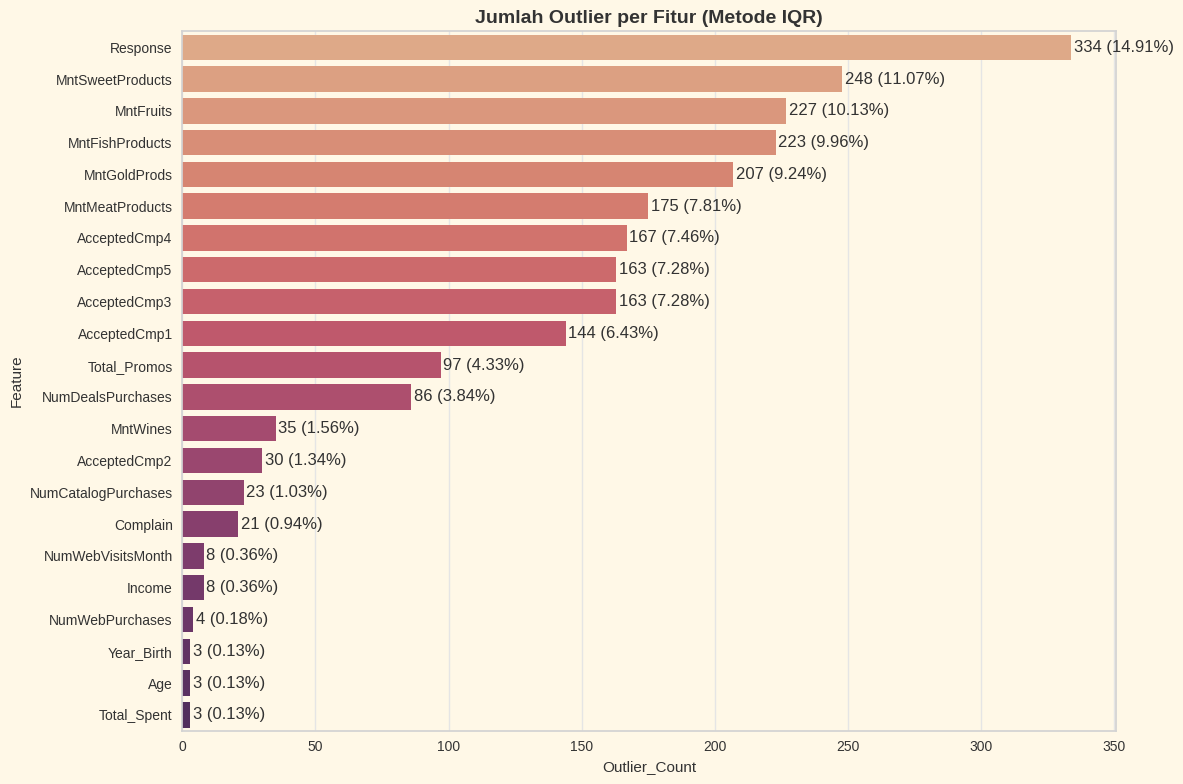

In [ ]:
# 2.2.2 Outlier & Categorical Feature
# Konstruksi fitur agregat sementara untuk keperluan eksplorasi outlier
df_audit = df.copy()
df_audit['Age'] = 2014 - df_audit['Year_Birth']
df_audit['Total_Spent'] = df_audit[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)
df_audit['Total_Promos'] = df_audit[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']].sum(axis=1)
df_audit['Total_Purchases'] = df_audit[['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].sum(axis=1)

def get_outlier_summary(data):
    outlier_list = []
    numeric_cols = data.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        count = data[(data[col] < lower_bound) | (data[col] > upper_bound)].shape[0]
        outlier_list.append({
            'Feature': col,
            'Outlier_Count': count,
            'Percentage (%)': (count / len(data)) * 100
        })
    return pd.DataFrame(outlier_list)

outlier_summary = get_outlier_summary(df_audit)
outlier_summary = outlier_summary[outlier_summary['Outlier_Count'] > 0].sort_values(by='Outlier_Count', ascending=False)

# Visualisasi ringkasan jumlah outlier
plt.figure(figsize=(12, 8))
ax_out = sns.barplot(data=outlier_summary, y='Feature', x='Outlier_Count', palette='flare')
plt.title("Jumlah Outlier per Fitur (Metode IQR)", fontsize=14, fontweight='bold')
for i, row in enumerate(outlier_summary.itertuples()):
    ax_out.text(row.Outlier_Count + 1, i, f"{row.Outlier_Count} ({row._3:.2f}%)", va='center')
plt.show()




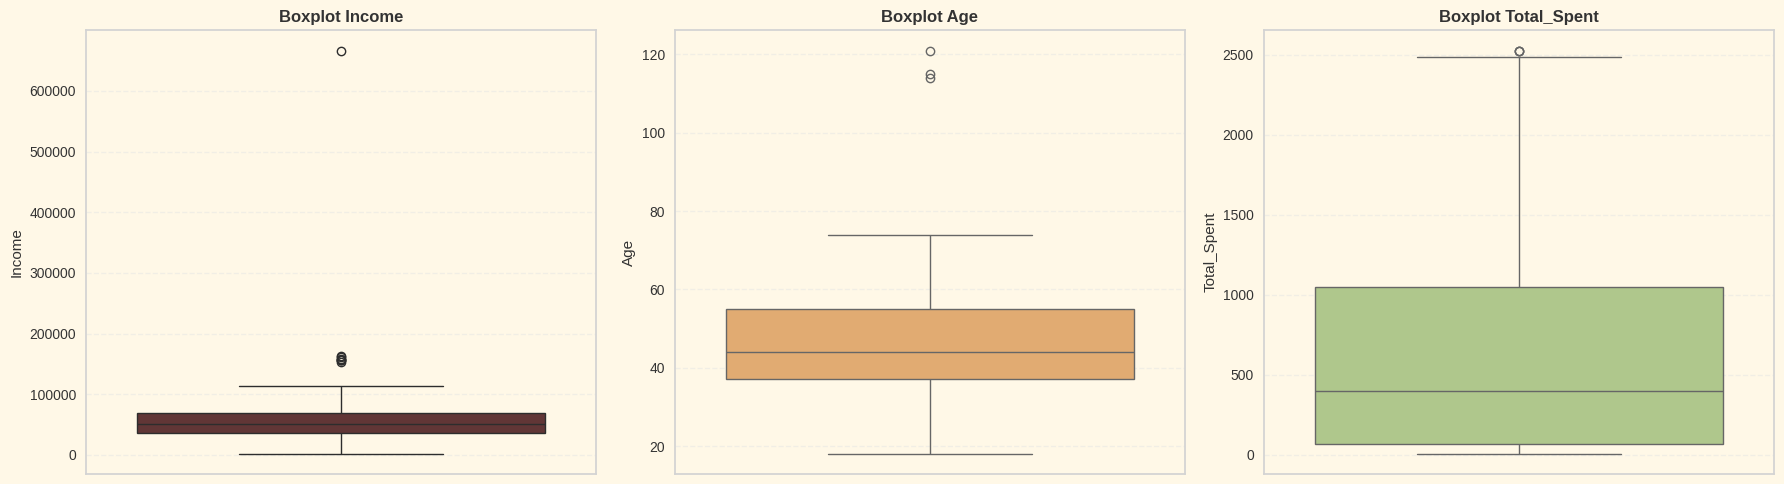

In [ ]:
# Boxplot fitur strategis
target_features = ['Income', 'Age', 'Total_Spent']
plt.figure(figsize=(18, 5))
colors = ['#682F2F', '#F3AB60', '#B1D182']
for i, col in enumerate(target_features):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df_audit[col], color=colors[i], fliersize=6)
    plt.title(f"Boxplot {col}", fontsize=12, fontweight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



In [ ]:
# Inspeksi detail data outlier
print("Detail Data Outlier pada Fitur Utama:")
for col in target_features:
    Q1 = df_audit[col].quantile(0.25)
    Q3 = df_audit[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_audit[(df_audit[col] < lower_bound) | (df_audit[col] > upper_bound)]
    print(f"\nFitur: {col.upper()} | Jumlah: {len(outliers)} | Batas Normal: {lower_bound:.2f} s/d {upper_bound:.2f}")
    if not outliers.empty:
        display(outliers[['ID', 'Year_Birth','Age', 'Income', 'Total_Spent', 'Total_Purchases', 'Total_Promos']]
                .sort_values(by=col, ascending=False).head(5))


Detail Data Outlier pada Fitur Utama:

Fitur: INCOME | Jumlah: 8 | Batas Normal: -14525.50 s/d 118350.50


,ID,Year_Birth,Age,Income,Total_Spent,Total_Purchases,Total_Promos
2233,9432,1977,37,666666.0,62,7,0
617,1503,1976,38,162397.0,107,1,0
687,1501,1982,32,160803.0,1717,29,0
1300,5336,1971,43,157733.0,59,2,0
164,8475,1973,41,157243.0,1608,22,0



Fitur: AGE | Jumlah: 3 | Batas Normal: 10.00 s/d 82.00


,ID,Year_Birth,Age,Income,Total_Spent,Total_Purchases,Total_Promos
239,11004,1893,121,60182.0,22,3,0
339,1150,1899,115,83532.0,1853,14,1
192,7829,1900,114,36640.0,65,5,0



Fitur: TOTAL_SPENT | Jumlah: 3 | Batas Normal: -1396.38 s/d 2510.62


,ID,Year_Birth,Age,Income,Total_Spent,Total_Purchases,Total_Promos
1179,5735,1991,23,90638.0,2525,17,1
1572,5350,1991,23,90638.0,2525,17,2
1492,1763,1988,26,87679.0,2524,28,4


Deteksi outlier dilakukan menggunakan metode $IQR$ untuk membedakan antara noise yang bersifat merusak integritas data (*Data Error/invalid*) dan nilai ekstrem yang memiliki nilai informasi bisnis.
Berdasarkan temuan pada tahap ini:
* Fitur Kampanye (Response, AcceptedCmp): Mencatat persentase outlier tertinggi hingga 14.91%. Setelah ditinjau kembali, temuan ini bukan merupakan kerusakan data, melainkan refleksi dari class imbalance. Mayoritas pelanggan tidak merespons kampanye (nilai 0), sehingga kelompok minoritas yang merespons (nilai 1) secara statistik terdeteksi sebagai outlier.

* Fitur Pengeluaran (Mnt... & Total_Spent) menunjukkan jumlah outlier cukup banyak. Namun,jika melihat gambaran dari **statistik deskriptif sebelumnya**, nilai maksimum dan minimum pada fitur-fitur tersebut (seperti `Total_Spent` sebesar 2.525 atau `MntMeatProducts` sebesar 1.725) masih berada dalam rentang kewajaran logika dan ekonomi (*plausible*).Nilai tersebut merepresentasikan profil pelanggan **"High-Value"** yang riil sehingga akan dipertahankan karena mengandung informasi bisnis yang berharga untuk segmentasi.

kemudian, Fitur **Income** dan **Age** dilakukan pengecekan lebih lanjut untuk memvalidasi apakah anomali tersebut merupakan kesalahan input atau nilai ekstrem yang valid. Berdasarkan investigasi baris data:
* Pada fitur **Age**, ditemukan tiga observasi dengan usia **114 hingga 121 tahun**. Temuan ini diklasifikasikan sebagai anomali biologis yang tidak logis dalam konteks pelanggan aktif saat ini.
* Pada fitur **Income**, ditemukan nilai ekstrem **$666.666** (ID 11191).jika melihat fitur lainnya pada baris tersebut, misalnya nilai `Total_Spent` pelanggan tersebut hanya sebesar **62**,ini mengindikasikan adanya ketidakkonsistenan data atau *entry error*.


> Catatan: Batas bawah bernilai negatif karena secara matematis nilai pengurang $1.5 \times \text{IQR}$ lebih besar daripada nilai $Q1$.


## 2.3 Distribution & Correlation

In [ ]:
# Definisi Kelompok Fitur
continuous_features = [
    'Income', 'Age', 'Recency', 'Total_Spent', 'Total_Purchases',
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
    'MntSweetProducts', 'MntGoldProds', 'NumWebVisitsMonth',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases'
]

mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
place_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']

#
promo_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']


# Konstruksi agregat anak untuk kebutuhan audit
df_audit['Total_Children'] = df_audit['Kidhome'] + df_audit['Teenhome']

2.3.1 Analisis Skewness Fitur Kontinu


,Skewness
Income,6.763487
MntSweetProducts,2.136081
MntFruits,2.102063
MntMeatProducts,2.083233
MntFishProducts,1.919769
MntGoldProds,1.886106
NumCatalogPurchases,1.880989
NumWebPurchases,1.382794
MntWines,1.175771
Total_Spent,0.860841


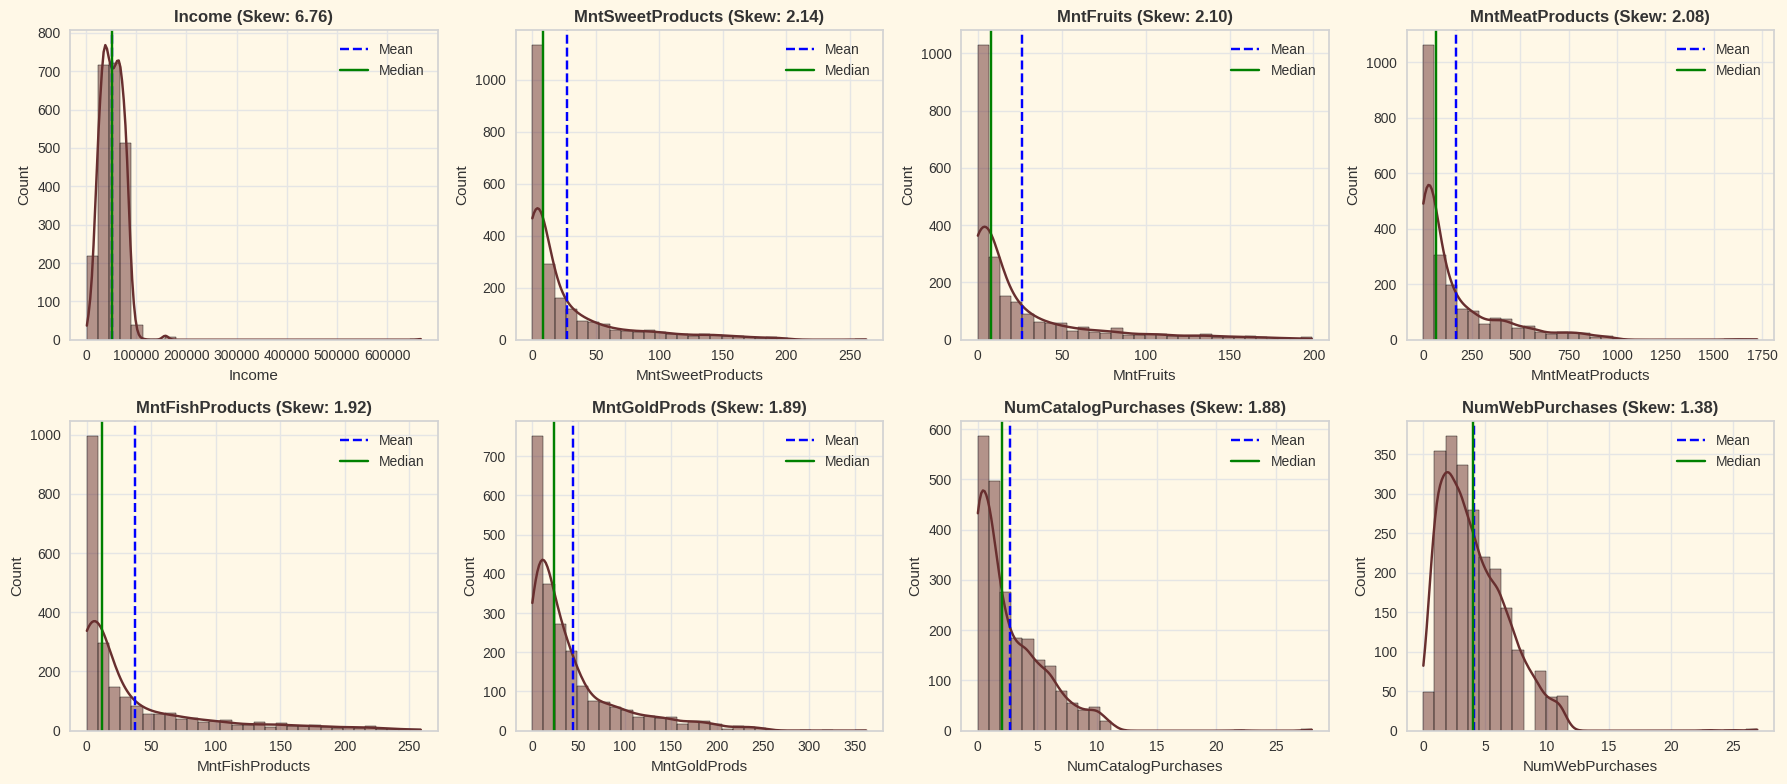

In [ ]:
# 2.3.1 Distribusi Fitur Kontinu (Skewness & KDE Plot)
print("2.3.1 Analisis Skewness Fitur Kontinu")
skewness_values = df_audit[continuous_features].skew().sort_values(ascending=False)
display(pd.DataFrame({'Skewness': skewness_values}).head(10))

# Visualisasi KDE (Menampilkan 6 fitur dengan kemiringan tertinggi)
plt.figure(figsize=(18, 8))
for i, col in enumerate(skewness_values.index[:8]):
    plt.subplot(2, 4, i+1)
    sns.histplot(df_audit[col], kde=True, color='#682F2F', bins=30)
    plt.axvline(df_audit[col].mean(), color='blue', linestyle='--', label='Mean')
    plt.axvline(df_audit[col].median(), color='green', linestyle='-', label='Median')
    plt.title(f'{col} (Skew: {df_audit[col].skew():.2f})', fontsize=12, fontweight='bold')
    plt.legend()
plt.tight_layout()
plt.show()


2.3.2 Distribusi Demografi Pelanggan


/tmp/ipykernel_162/4151977005.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_audit, x='Education', ax=axes[0], palette='viridis', order=df_audit['Education'].value_counts().index)
/tmp/ipykernel_162/4151977005.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_audit, x='Marital_Status', ax=axes[1], palette='mako', order=df_audit['Marital_Status'].value_counts().index)
/tmp/ipykernel_162/4151977005.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_audit, x='Total_Children', ax=axes[2], palette='flare', 

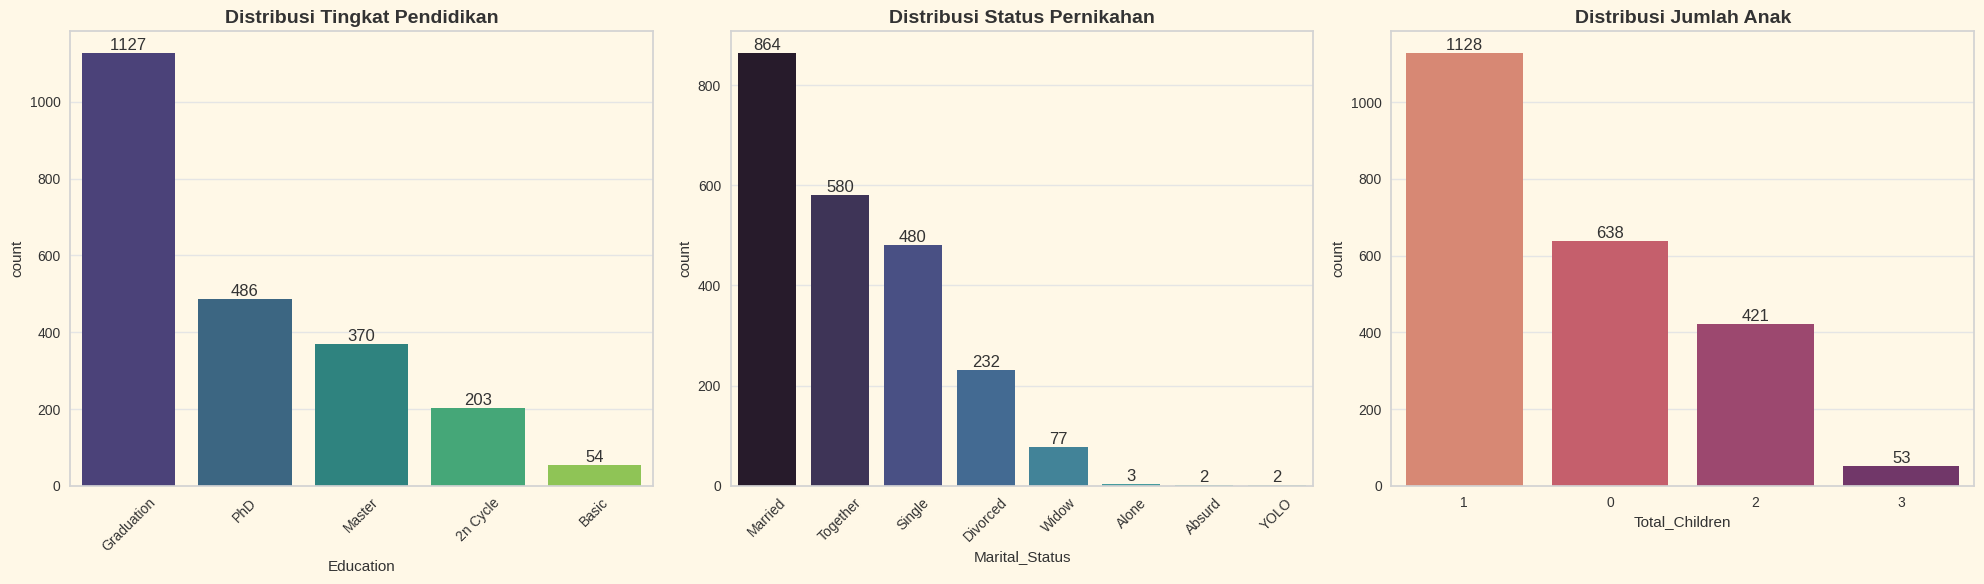

In [ ]:
# 2.3.2 Distribusi Demografi (Kategorikal & Diskrit)
print("\n2.3.2 Distribusi Demografi Pelanggan")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.countplot(data=df_audit, x='Education', ax=axes[0], palette='viridis', order=df_audit['Education'].value_counts().index)
axes[0].set_title('Distribusi Tingkat Pendidikan', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

sns.countplot(data=df_audit, x='Marital_Status', ax=axes[1], palette='mako', order=df_audit['Marital_Status'].value_counts().index)
axes[1].set_title('Distribusi Status Pernikahan', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

sns.countplot(data=df_audit, x='Total_Children', ax=axes[2], palette='flare', order=df_audit['Total_Children'].value_counts().index)
axes[2].set_title('Distribusi Jumlah Anak', fontsize=14, fontweight='bold')
for p in axes[2].patches:
    axes[2].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

plt.tight_layout()
plt.show()


* Marital Status:

  * Ditemukan label yang tidak standar dan tidak memiliki definisi bisnis yang jelas, yaitu Alone (3), Absurd (2), dan YOLO (2).Label ini merupakan noise yang akan menambah cardinality tanpa memberikan nilai informasi yang signifikan bagi algoritma clustering.

* Education Level Distribution:

  * Distribusi pendidikan didominasi oleh kelompok Graduation (1.127), diikuti oleh PhD dan Master. Terdapat kategori 2n Cycle, yang dalam konteks sistem pendidikan tertentu setara dengan Master, namun di sini berdiri sendiri.



2.3.3 Analisis Kinerja Bisnis (Produk, Channel, Promo)


/tmp/ipykernel_162/1226068566.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=spending_shares.values, y=spending_shares.index, palette="flare", ax=axes[0])
/tmp/ipykernel_162/1226068566.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=channel_dist.values, y=channel_dist.index, palette="crest", ax=axes[1])
/tmp/ipykernel_162/1226068566.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=campaign_df, x='Rate (%)', y='Fitur', palette="magma", ax=axes[2])


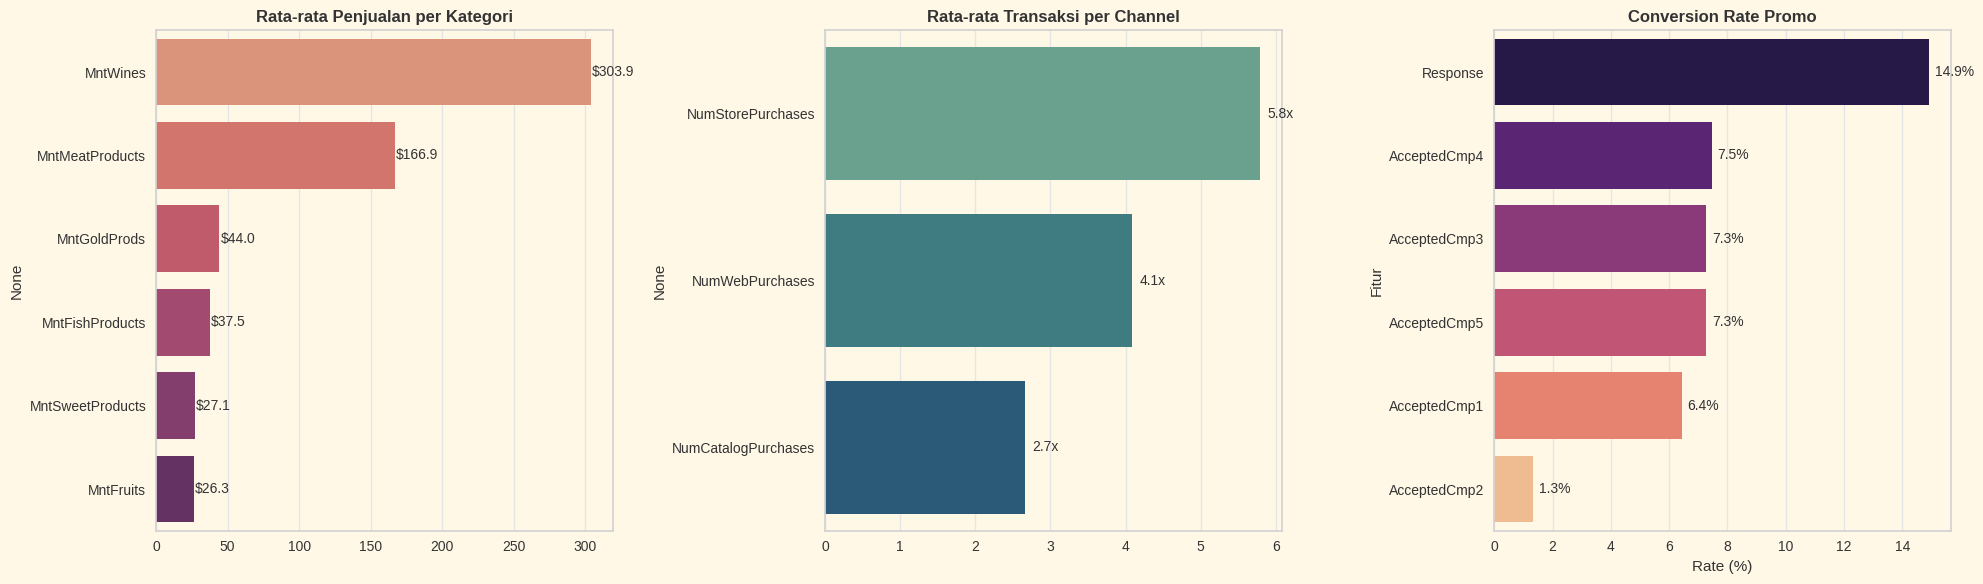

In [ ]:
# 2.3.3 Konteks Bisnis: Produk, Channel & Promo
print("\n2.3.3 Analisis Kinerja Bisnis (Produk, Channel, Promo)")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Rata-rata Pengeluaran Produk
spending_shares = df_audit[mnt_cols].mean().sort_values(ascending=False)
sns.barplot(x=spending_shares.values, y=spending_shares.index, palette="flare", ax=axes[0])
axes[0].set_title("Rata-rata Penjualan per Kategori", fontweight='bold')
for i, v in enumerate(spending_shares.values):
    axes[0].text(v + 1, i, f"${v:.1f}", va='center', fontsize=10)

# Rata-rata Pembelian per Channel
channel_dist = df_audit[place_cols].mean().sort_values(ascending=False)
sns.barplot(x=channel_dist.values, y=channel_dist.index, palette="crest", ax=axes[1])
axes[1].set_title("Rata-rata Transaksi per Channel", fontweight='bold')
for i, v in enumerate(channel_dist.values):
    axes[1].text(v + 0.1, i, f"{v:.1f}x", va='center', fontsize=10)

# Conversion Rate Promo (Murni KPI Marketing)
campaign_summary = []
for col in promo_cols:
    pct = (df_audit[col].sum() / len(df_audit)) * 100
    campaign_summary.append({'Fitur': col, 'Rate (%)': pct})
campaign_df = pd.DataFrame(campaign_summary).sort_values(by='Rate (%)', ascending=False)

sns.barplot(data=campaign_df, x='Rate (%)', y='Fitur', palette="magma", ax=axes[2])
axes[2].set_title("Conversion Rate Promo", fontweight='bold')
for i, v in enumerate(campaign_df['Rate (%)']):
    axes[2].text(v + 0.2, i, f"{v:.1f}%", va='center', fontsize=10)

plt.tight_layout()
plt.show()



2.3.4 Deteksi Redundansi (Matriks Korelasi)


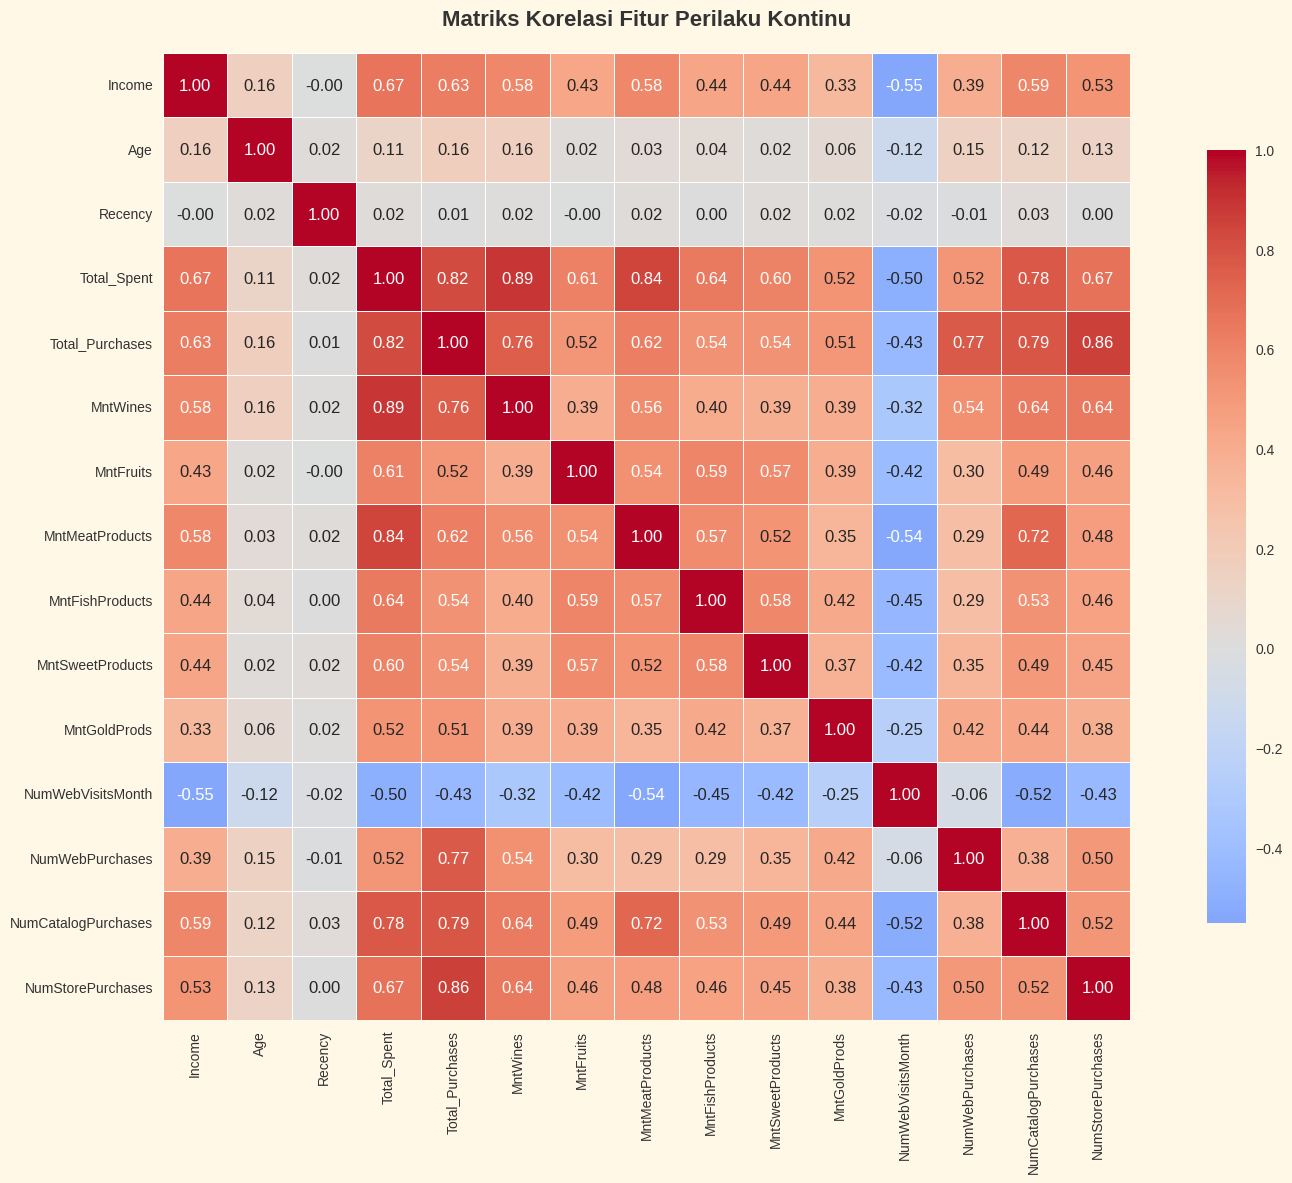

Daftar Pasangan Fitur Redundan (Korelasi > 0.70):


Nilai Korelasi
MntWines            Total_Spent                0.891839
Total_Purchases     NumStorePurchases          0.855454
MntMeatProducts     Total_Spent                0.842965
Total_Purchases     Total_Spent                0.820687
                    NumCatalogPurchases        0.785609
NumCatalogPurchases Total_Spent                0.778577
Total_Purchases     NumWebPurchases            0.765923
                    MntWines                   0.756490
MntMeatProducts     NumCatalogPurchases        0.723827

In [ ]:
# 2.3.4 Analisis Korelasi & Multikolinearitas
print("\n2.3.4 Deteksi Redundansi (Matriks Korelasi)")
corr_matrix = df_audit[continuous_features].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    center=0,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={"shrink": .8},
    square=True # Memastikan sel tetap kotak sempurna
)
plt.title('Matriks Korelasi Fitur Perilaku Kontinu', fontsize=16, fontweight='bold', pad=20)
plt.show()

# Ekstraksi Pasangan Fitur dengan Korelasi Tinggi (> 0.70)
high_corr = corr_matrix.unstack().sort_values(ascending=False)
high_corr_filtered = high_corr[(high_corr > 0.70) & (high_corr < 1.0)].drop_duplicates()

print("Daftar Pasangan Fitur Redundan (Korelasi > 0.70):")
if not high_corr_filtered.empty:
    display(pd.DataFrame(high_corr_filtered, columns=['Nilai Korelasi']))

# **3. Data Preparation**

## 3.1 Data Cleaning

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

In [ ]:
# 3.1 Data Cleaning
# Menghapus missing values dan outlier ekstrem berdasarkan temuan
df_prep = df.copy().dropna()

# Filter outlier ekstrem & anomali (Berdasarkan audit di Section 2)
df_prep = df_prep[(df_prep['Year_Birth'] >= 1900) & (df_prep['Income'] < 600000)]

print(f"Pembersihan Selesai. Sisa data: {len(df_prep)} baris.")

Pembersihan Selesai. Sisa data: 2213 baris.


## 3.2 Feature Engineering

In [ ]:
#3.2 Feature Engineering

# Pilar People: Mengubah status menjadi angka/biner
df_prep['Age'] = 2014 - df_prep['Year_Birth']
df_prep['Education_Level'] = df_prep['Education'].map({
    'Basic': 0, 'Graduation': 1, '2n Cycle': 2, 'Master': 2, 'PhD': 3
})
df_prep['Living_With'] = df_prep['Marital_Status'].replace({
    'Married': 1, 'Together': 1, 'Single': 0, 'Divorced': 0,
    'Widow': 0, 'Alone': 0, 'Absurd': 0, 'YOLO': 0
})

# Pilar Household & Tenure
df_prep['Total_Children'] = df_prep['Kidhome'] + df_prep['Teenhome']

# Menghitung masa berlangganan (Tenure)
df_prep['Dt_Customer'] = pd.to_datetime(df_prep['Dt_Customer'], dayfirst=True)
df_prep['Customer_Tenure'] = (df_prep['Dt_Customer'].max() - df_prep['Dt_Customer']).dt.days

# Pilar Product & Place (Agregasi)
mnt_cols = [c for c in df_prep.columns if 'Mnt' in c]
df_prep['Total_Spent'] = df_prep[mnt_cols].sum(axis=1)

purchase_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df_prep['Total_Purchases'] = df_prep[purchase_cols].sum(axis=1)

# Pilar Promotion (Agregasi untuk Skenario B dan C)
promo_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
df_prep['Total_Promos'] = df_prep[promo_cols].sum(axis=1)

print("Feature Engineering Selesai. 29 fitur siap diuji.")

Feature Engineering Selesai. 29 fitur siap diuji.


/tmp/ipykernel_162/2499514283.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_prep['Living_With'] = df_prep['Marital_Status'].replace({


## 3.3 Feature Selection

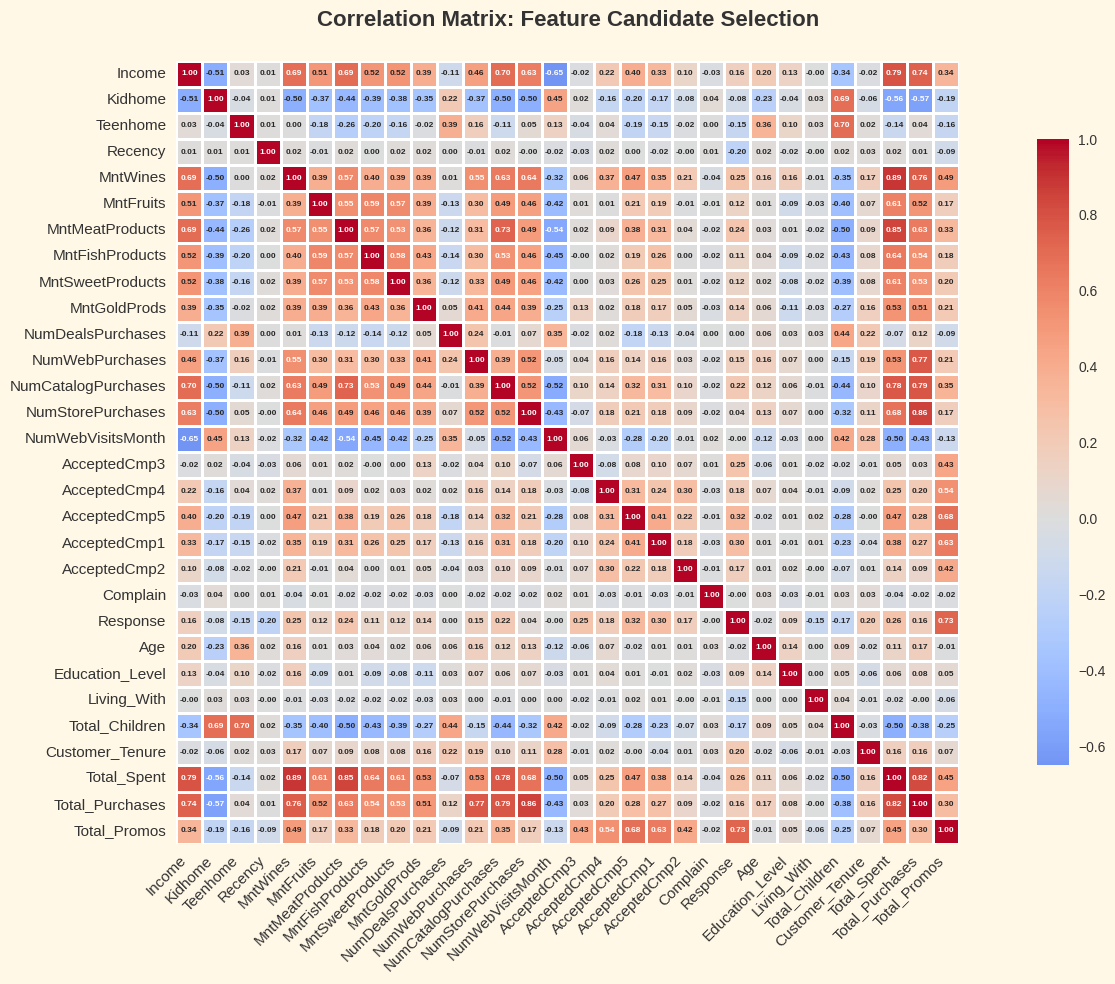


--- Daftar Korelasi Tertinggi (Positif & Negatif) ---


,,Nilai Korelasi
Total_Spent,MntWines,0.893033
NumStorePurchases,Total_Purchases,0.857954
MntMeatProducts,Total_Spent,0.845580
Total_Purchases,Total_Spent,0.823432
Total_Spent,Income,0.792793
Total_Purchases,NumCatalogPurchases,0.787080
NumCatalogPurchases,Total_Spent,0.780282
NumWebPurchases,Total_Purchases,0.770389
Total_Purchases,MntWines,0.757344
Income,Total_Purchases,0.742759


In [ ]:
# 3.3 Feature Selection

# A. Identifikasi Fitur Tidak Digunakan (Blacklist)
features_unused = [
    'ID',                # Identitas unik
    'Year_Birth',        # Redundan (digantikan Age)
    'Dt_Customer',       # Redundan (digantikan Customer_Tenure)
    'Education',         # Kategorikal mentah
    'Marital_Status',    # Kategorikal mentah
    'Z_CostContact',     # Fitur konstan
    'Z_Revenue'          # Fitur konstan
]

# B. Heatmap Audit Redundansi (Pendukung Keputusan)
plt.figure(figsize=(16, 10))
numeric_all = df_prep.select_dtypes(include=[np.number]).drop(columns=features_unused, errors='ignore')
corr_matrix = numeric_all.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=1.0,
    linecolor='white',
    cbar_kws={"shrink": .8},
    square=True,
    annot_kws={"size": 6, "weight": "bold"}
)

plt.title("Correlation Matrix: Feature Candidate Selection",
          fontsize=16, fontweight='bold', pad=25, color='#333333')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

plt.show()

# C. Sorting Korelasi Tertinggi (Audit Multikolinearitas)
# Mengambil pasangan korelasi, mengurutkan berdasarkan nilai absolut tertinggi
pairs = corr_matrix.unstack().sort_values(key=abs, ascending=False)
# Menghapus korelasi diri sendiri (1.0) dan duplikasi pasangan (A-B vs B-A)
high_corr = pairs[pairs < 1.0].drop_duplicates()

print("\n--- Daftar Korelasi Tertinggi (Positif & Negatif) ---")
# Menampilkan 15 pasangan fitur dengan korelasi terkuat untuk justifikasi PCA/Seleksi
display(pd.DataFrame(high_corr, columns=['Nilai Korelasi']).head(15))


In [ ]:
# D. Definisi Skenario Fitur Eksperimen
# Berdasarkan audit korelasi, kita membagi eksperimen ke dalam 3 level granularitas:

# [A] Model Champion: 26 Fitur Granular (Full Spectrum)
features_A = [
    'Age', 'Income', 'Education_Level', 'Living_With', 'Kidhome', 'Teenhome', 'Customer_Tenure',
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Recency',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response',
    'NumDealsPurchases', 'Complain'
]

# [B] Model Agregasi: 21 Fitur (Sinyal Promo Terpusat)
features_B = [
    'Age', 'Income', 'Education_Level', 'Living_With', 'Customer_Tenure', 'Kidhome', 'Teenhome',
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Recency',
    'Total_Promos', 'NumDealsPurchases', 'Complain'
]

# [C] Model Sinyal Murni: 15 Fitur (Behavioral Only - No Noise)
features_C = [
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Customer_Tenure',
    'Recency', 'Total_Promos', 'NumDealsPurchases', 'Complain'
]

print("\n4.3 Feature Selection Selesai. 3 skenario fitur siap diuji.")


4.3 Feature Selection Selesai. 3 skenario fitur siap diuji.


Tujuan dari pengujian tiga skenario ini adalah untuk menemukan **"Sweet Spot" antara kedalaman wawasan bisnis dan ketajaman separasi matematis**.

---

**[A] 26 Fitur Granular (Full Spectrum)**

**Tujuan:**  
Menangkap seluruh spektrum data (Demografi + Perilaku + Respon Kampanye Individu) untuk mendapatkan resolusi persona tertinggi.

**Hipotesis:**  
Meskipun berisiko memiliki noise tinggi, skenario ini memungkinkan identitas klaster yang lebih spesifik (misal: membedakan respon tiap jenis kampanye).

---

**[B] 21 Fitur (Sinyal Promo Terpusat)**

**Tujuan:**  
Meningkatkan **Signal-to-Noise Ratio (SNR)** dengan meringkas variabel kampanye menjadi satu fitur intensitas (**Total_Promos**).

**Hipotesis:**  
Mengurangi dimensi variabel biner yang jarang terjadi (*sparse*) akan menstabilkan pusat klaster (DB Index membaik) tanpa kehilangan konteks demografi.

---

**[C] 15 Fitur (Behavioral Only – No Noise)**

**Tujuan:**  
Mengisolasi DNA perilaku belanja murni dengan membuang fitur demografi statis (Age, Education, Living_With).

**Hipotesis:**  
Menghasilkan skor **Silhouette tertinggi** karena algoritma hanya fokus pada variabel transaksional yang memiliki variansi tinggi, sehingga menghasilkan batas segmen yang paling tegas secara geometri.

## 3.4 Feature Scaling

Robust Scaler digunakan karena dataset ini memiliki sebaran data yang tidak normal dan mengandung banyak pencilan (outliers) strategis, seperti kelompok pelanggan dengan pendapatan dan pengeluaran yang ekstrim. Berbeda dengan Standard Scaler yang sensitif terhadap nilai rata-rata, Robust Scaler menggunakan basis Median dan Interquartile Range (IQR). Hal ini memastikan bahwa pusat koordinat data tetap stabil dan tidak terdistorsi oleh nilai ekstrem, sehingga algoritma K-Means dapat menghitung jarak antar pelanggan mayoritas secara lebih akurat tanpa menghilangkan identitas kelompok elit tersebut.

In [ ]:
# --- 3.4 Feature Scaling ---
# Menggunakan RobustScaler secara langsung pada data mentah (df_prep)

all_potential_features = list(set(features_A + features_B + features_C + ['Total_Spent'])) # Add 'Total_Spent' here
scaler = RobustScaler()
X_scaled_full = pd.DataFrame(scaler.fit_transform(df_prep[all_potential_features]), columns=all_potential_features)

print("4.4 Feature Scaling (RobustScaler) Global Selesai.")

4.4 Feature Scaling (RobustScaler) Global Selesai.


In [ ]:
X_scaled_full.head()

,MntGoldProds,Total_Promos,NumCatalogPurchases,Living_With,NumWebVisitsMonth,AcceptedCmp4,MntMeatProducts,MntWines,Income,Response,Age,Total_Spent,NumWebPurchases,Kidhome,NumDealsPurchases,AcceptedCmp5,AcceptedCmp3,Recency,AcceptedCmp2,AcceptedCmp1,NumStorePurchases,Customer_Tenure,Education_Level,Complain,MntSweetProducts,Teenhome,MntFruits,MntFishProducts
0,1.340426,1.0,2.00,-1.0,0.25,0.0,2.212963,0.956341,0.203634,1.0,0.722222,1.246170,1.00,0.0,0.5,0.0,0.0,0.18,0.0,0.0,-0.2,0.879656,0.0,0.0,2.50000,0.0,2.580645,3.404255
1,-0.404255,0.0,-0.25,-1.0,-0.25,0.0,-0.287037,-0.340956,-0.151169,0.0,0.888889,-0.377937,-0.75,1.0,0.0,0.0,0.0,-0.22,0.0,0.0,-0.6,-0.696275,0.0,0.0,-0.21875,1.0,-0.225806,-0.212766
2,0.361702,0.0,0.00,0.0,-0.50,0.0,0.273148,0.521830,0.609007,0.0,0.277778,0.387130,1.00,0.0,-0.5,0.0,0.0,-0.46,0.0,0.0,1.0,-0.126074,0.0,0.0,0.40625,0.0,1.322581,2.106383
3,-0.425532,0.0,-0.50,0.0,0.00,0.0,-0.222222,-0.340956,-0.743750,0.0,-0.777778,-0.351379,-0.50,1.0,0.0,0.0,0.0,-0.46,0.0,0.0,-0.2,-0.621777,0.0,0.0,-0.15625,0.0,-0.129032,-0.042553
4,-0.212766,0.0,0.25,0.0,-0.25,0.0,0.231481,-0.004158,0.208297,0.0,-0.611111,0.025536,0.25,1.0,1.5,0.0,0.0,0.90,0.0,0.0,0.2,-0.558739,2.0,0.0,0.59375,0.0,1.129032,0.723404


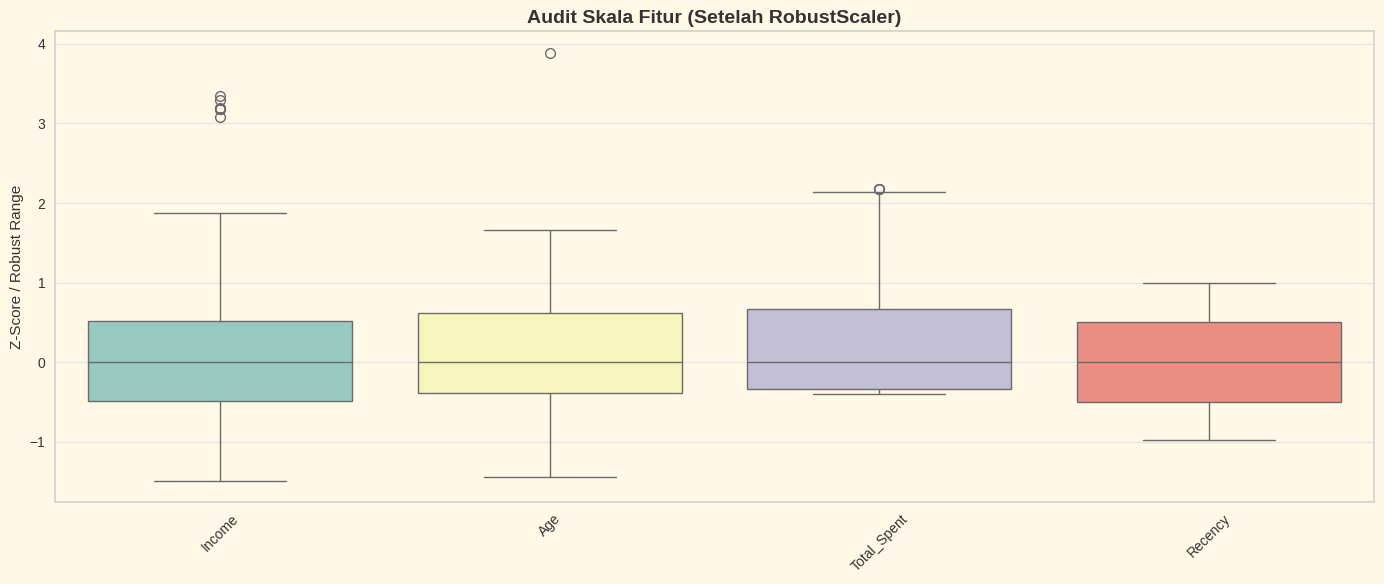

In [ ]:

# 4.5 PREPROCESSING AUDIT


def plot_preprocessing_audit(df_original, df_scaled, feature_name):
    """
    Menampilkan perbandingan distribusi fitur sebelum dan sesudah scaling.
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # --- BEFORE SCALING ---
    sns.histplot(df_original[feature_name], kde=True, ax=axes[0], color='#682F2F')
    axes[0].set_title(f"Distribusi {feature_name} (Original)\nSkewness: {df_original[feature_name].skew():.2f}", fontweight='bold')
    axes[0].set_xlabel("Nilai Asli (Dollar/Satuan)")

    # --- AFTER SCALING (ROBUST) ---
    sns.histplot(df_scaled[feature_name], kde=True, ax=axes[1], color='#B1D182')
    axes[1].set_title(f"Distribusi {feature_name} (Robust Scaled)\nSkewness: {df_scaled[feature_name].skew():.2f}", fontweight='bold')
    axes[1].set_xlabel("Skala Relatif (Median-Centered)")

    plt.tight_layout()
    plt.show()

# CARA PAKAI:
# Kita ambil fitur 'Income' sebagai representasi karena punya outlier paling tinggi.
# plot_preprocessing_audit(df_prep, X_scaled_full, 'Income')

# --- AUDIT BOXPLOT (Opsional tapi Tajam) ---
def plot_scaling_boxplot(df_scaled, features_to_show):
    """
    Menunjukkan bahwa semua fitur sekarang berada di lapangan permainan yang sama (Setara).
    """
    plt.figure(figsize=(14, 6))
    sns.boxplot(data=df_scaled[features_to_show], palette='Set3')
    plt.title("Audit Skala Fitur (Setelah RobustScaler)", fontsize=14, fontweight='bold')
    plt.ylabel("Z-Score / Robust Range")
    plt.xticks(rotation=45)
    plt.show()

plot_scaling_boxplot(X_scaled_full, ['Income', 'Age', 'Total_Spent', 'Recency'])

In [ ]:
X_scaled_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2213 entries, 0 to 2212
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   MntGoldProds         2213 non-null   float64
 1   Total_Promos         2213 non-null   float64
 2   NumCatalogPurchases  2213 non-null   float64
 3   Living_With          2213 non-null   float64
 4   NumWebVisitsMonth    2213 non-null   float64
 5   AcceptedCmp4         2213 non-null   float64
 6   MntMeatProducts      2213 non-null   float64
 7   MntWines             2213 non-null   float64
 8   Income               2213 non-null   float64
 9   Response             2213 non-null   float64
 10  Age                  2213 non-null   float64
 11  Total_Spent          2213 non-null   float64
 12  NumWebPurchases      2213 non-null   float64
 13  Kidhome              2213 non-null   float64
 14  NumDealsPurchases    2213 non-null   float64
 15  AcceptedCmp5         2213 non-null   f

## 3.5 PCA

Karena adanya redundansi di mana beberapa fitur memiliki korelasi yang sangat tinggi (multikolinearitas)—seperti hubungan erat antara Income dengan berbagai kategori Spending—PCA diterapkan untuk mendekorelasikan variabel-variabel tersebut ke dalam sumbu baru yang saling tegak lurus (Ortogonal). Langkah ini krusial untuk mencegah terjadinya bias 'bobot ganda' (double counting) dalam perhitungan jarak Euclidean pada K-Means. Dengan PCA, kita berhasil menyaring sinyal perilaku utama dan membuang kebisingan (noise) data, sehingga menghasilkan separasi klaster yang jauh lebih tajam, stabil, dan memiliki makna bisnis yang lebih jelas.

### Find the Best PC for Clustering

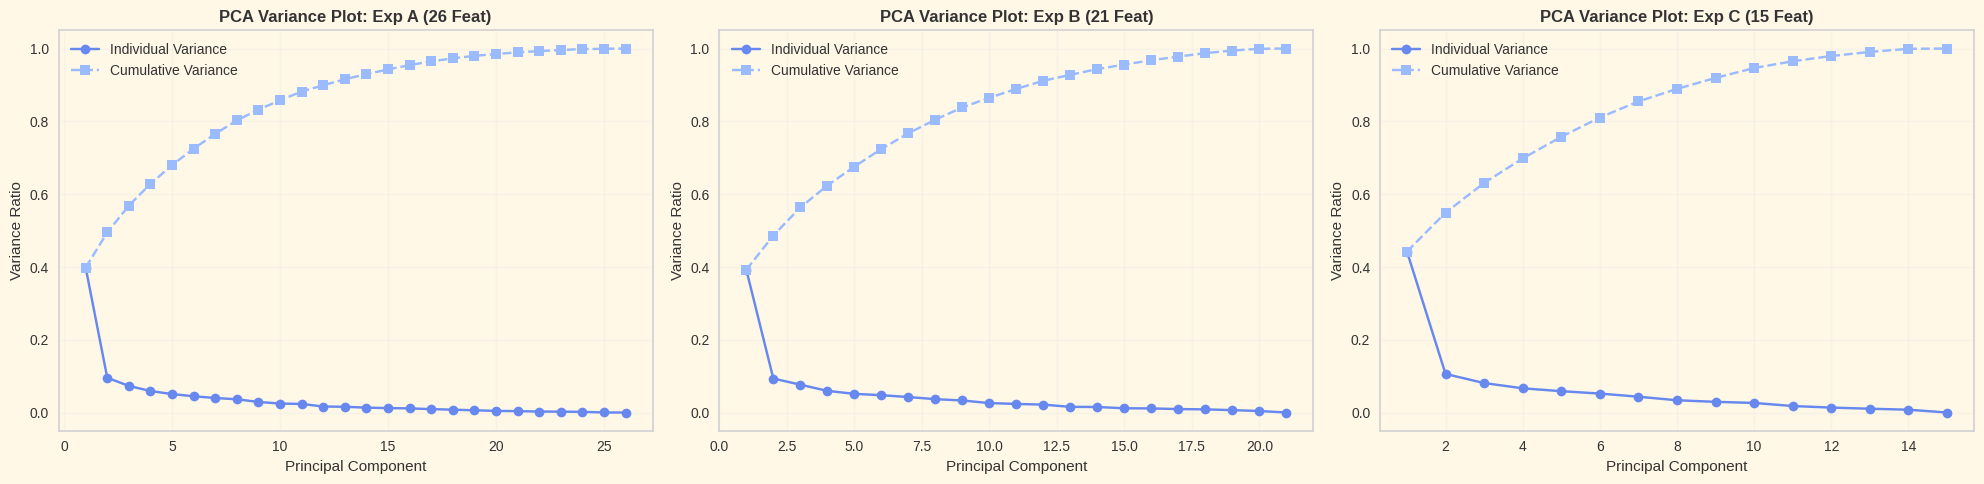

In [ ]:
#  PCA METHODOLOGY: EXPLORATION TO REDUCTION

scenarios = [
    {'name': 'Exp A (26 Feat)', 'features': features_A},
    {'name': 'Exp B (21 Feat)', 'features': features_B},
    {'name': 'Exp C (15 Feat)', 'features': features_C}
]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for i, scn in enumerate(scenarios):
    pca_explore = PCA().fit(X_scaled_full[scn['features']])
    exp_var = pca_explore.explained_variance_ratio_
    cum_var = np.cumsum(exp_var)

    axes[i].plot(range(1, len(exp_var)+1), exp_var, marker='o', label='Individual Variance')
    axes[i].plot(range(1, len(cum_var)+1), cum_var, marker='s', linestyle='--', label='Cumulative Variance')
    axes[i].set_title(f"PCA Variance Plot: {scn['name']}", fontweight='bold')
    axes[i].set_xlabel('Principal Component')
    axes[i].set_ylabel('Variance Ratio')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Applying PCA with the best number of PCs

Kami menetapkan 2 Principal Components (PC) sebagai basis pemodelan karena grafik Scree Plot menunjukkan penurunan variansi yang sangat tajam tepat sebelum PC2, di mana garis mulai melandai secara konsisten (Elbow Method). Secara teknis, dua komponen ini sudah cukup untuk menangkap "sinyal emas" perilaku pelanggan—yaitu dimensi Kapasitas Ekonomi dan Strategi Belanja—sambil membuang sisa variansi yang dianggap sebagai stochastic noise.


In [ ]:
# --- 5.2 Tahap 2: Reduksi PCA (n=2) & Audit Loadings ---
# SEKARANG: Hasil PCA disimpan ke dalam variabel tersendiri di dalam list scenarios
print("\n--- AUDIT PCA LOADINGS (Berdasarkan Reduksi n=2) ---")
pca_results_summary = []

for scn in scenarios:
    pca_final = PCA(n_components=2, random_state=42)
    # Simpan hasil transformasi PCA ke dalam dictionary skenario agar tidak dihitung ulang
    scn['X_pca'] = pca_final.fit_transform(X_scaled_full[scn['features']])

    # Audit Loadings
    loadings = pd.DataFrame(pca_final.components_.T, columns=['PC1', 'PC2'], index=scn['features'])

    print(f"\n>> Skenario: {scn['name']}")
    print("Top Fitur PC1:")
    display(loadings[['PC1']].sort_values(by='PC1', ascending=False).head(10))
    print("Top Fitur PC2:")
    display(loadings[['PC2']].sort_values(by='PC2', ascending=False).head(10))



--- AUDIT PCA LOADINGS (Berdasarkan Reduksi n=2) ---

>> Skenario: Exp A (26 Feat)
Top Fitur PC1:


,PC1
MntFruits,0.440676
MntSweetProducts,0.438179
MntFishProducts,0.401415
MntMeatProducts,0.354540
MntGoldProds,0.282109
NumCatalogPurchases,0.238190
Income,0.213337
MntWines,0.194708
NumStorePurchases,0.185194
NumWebPurchases,0.142454


Top Fitur PC2:


,PC2
NumDealsPurchases,0.661979
MntGoldProds,0.388618
NumWebPurchases,0.322756
Teenhome,0.237497
MntWines,0.209019
NumStorePurchases,0.162830
Customer_Tenure,0.160205
Age,0.148174
NumWebVisitsMonth,0.140383
Education_Level,0.134701



>> Skenario: Exp B (21 Feat)
Top Fitur PC1:


...

,PC2
NumDealsPurchases,0.628532
MntGoldProds,0.368731
NumWebPurchases,0.318878
MntWines,0.235488
Teenhome,0.226395
Education_Level,0.161764
NumStorePurchases,0.158709
Customer_Tenure,0.153461
Age,0.147600
Total_Promos,0.141518



>> Skenario: Exp C (15 Feat)
Top Fitur PC1:


,PC1
MntFruits,0.454884
MntSweetProducts,0.452263
MntFishProducts,0.413473
MntMeatProducts,0.361828
MntGoldProds,0.292064
NumCatalogPurchases,0.242547
MntWines,0.198812
NumStorePurchases,0.186291
NumWebPurchases,0.145077
Total_Promos,0.139157


Top Fitur PC2:


,PC2
NumDealsPurchases,0.668443
MntGoldProds,0.456035
NumWebPurchases,0.314049
MntWines,0.203253
Customer_Tenure,0.187797
NumWebVisitsMonth,0.177864
Total_Promos,0.145400
NumStorePurchases,0.135230
NumCatalogPurchases,0.106889
Complain,-0.001103


Nilai loading tersebut merepresentasikan kontribusi setiap fitur pada setiap principle component.

# **4. Clustering Experiments**

## 4.1 Find Best number of clusters

--- Menjalankan Pemilihan jumlah K optimal K-Means dengan Yellowbrick ---


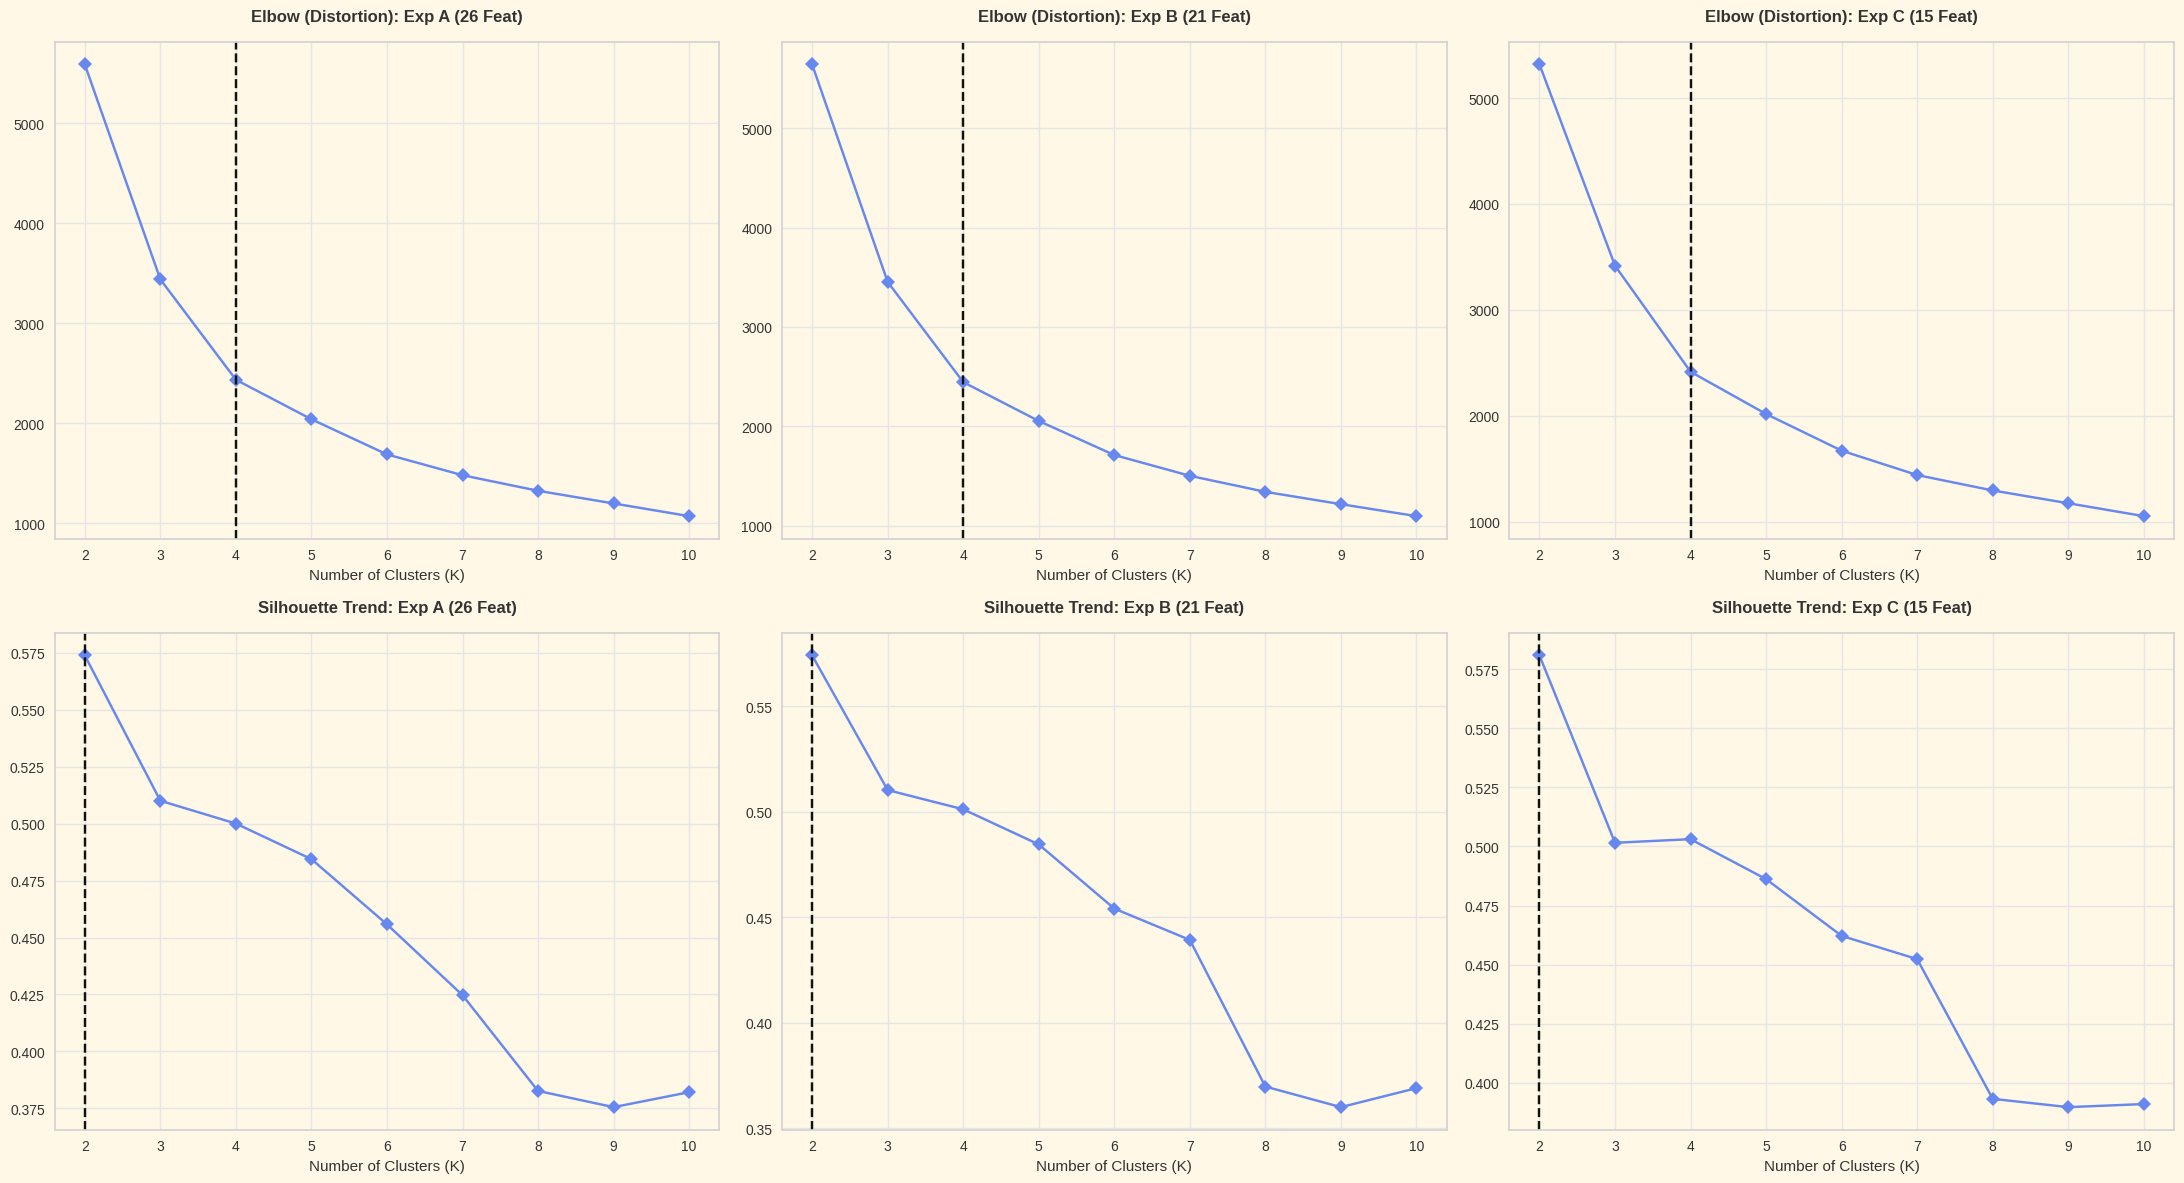

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(22, 12))

print("--- Menjalankan Pemilihan jumlah K optimal K-Means dengan Yellowbrick ---")

for i, scn in enumerate(scenarios):
    # Memanggil data PCA yang sudah disimpan sebelumnya (Efisien & Clean)
    X_pca_k = scn['X_pca']

    # --- BARIS 1: ELBOW METHOD (Distortion Score) ---
    model_dist = KMeans(init='k-means++', n_init=10, random_state=42)
    visualizer_elbow = KElbowVisualizer(
        model_dist, k=(2,11), ax=axes[0, i],
        timings=False, locate_elbow=True
    )
    visualizer_elbow.fit(X_pca_k)
    axes[0, i].set_title(f"Elbow (Distortion): {scn['name']}", fontweight='bold', pad=15)
    axes[0, i].set_xlabel("Number of Clusters (K)")

    # --- BARIS 2: SILHOUETTE SCORE TREND ---
    model_sil = KMeans(init='k-means++', n_init=10, random_state=42)
    visualizer_sil = KElbowVisualizer(
        model_sil, k=(2,11), metric='silhouette', ax=axes[1, i],
        timings=False, locate_elbow=True
    )
    visualizer_sil.fit(X_pca_k)
    axes[1, i].set_title(f"Silhouette Trend: {scn['name']}", fontweight='bold', pad=15)
    axes[1, i].set_xlabel("Number of Clusters (K)")

plt.tight_layout()
plt.show()

berdasarkan hasil grafik elbow , jumlah klaster yang optimal secara konsisten adalah 4. ini ditunjukkan pada titik siku yang konsisten di semua kombinasi fitur.

## 4.2 Run Clustering with K-Means

In [ ]:
results = []
K_FINAL = 4

for scn in scenarios:
    # 1. Mengambil data PCA yang sudah disimpan di Section 5.2
    X_pca = scn['X_pca']

    # 2. Inisialisasi dan Fit K-Means
    kmeans = KMeans(n_clusters=K_FINAL, init='k-means++', n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_pca)

    # 3. Hitung Metrik Evaluasi
    sil_score = silhouette_score(X_pca, labels)
    dbi_score = davies_bouldin_score(X_pca, labels)

    # 4. Simpan hasil ke dalam list results untuk dashboard
    results.append({
        'name': scn['name'],
        'features': scn['features'],
        'X_pca': X_pca,
        'labels': labels,
        'silhouette': sil_score,
        'dbi': dbi_score,
        'model': kmeans
    })

## 4.3 Evaluation & Quick Profilling Comparison


[Visualisasi A] Perbandingan Separasi Klaster (PCA 2D)


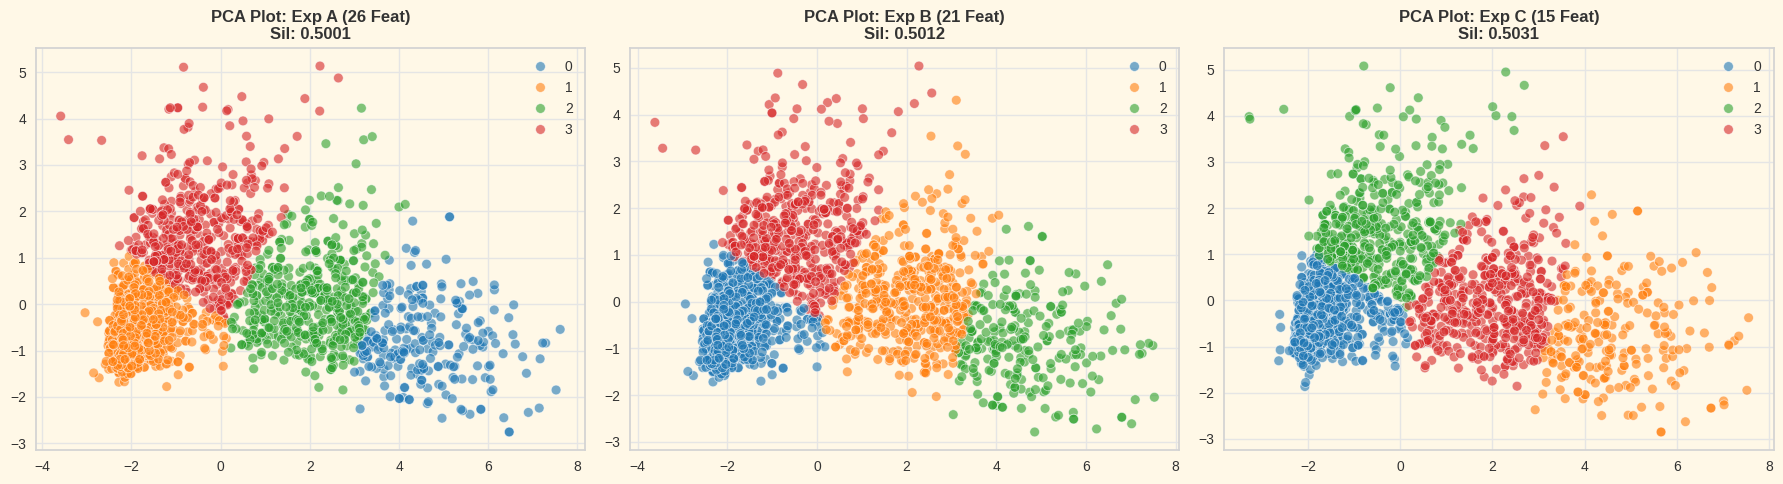


[Visualisasi B] Perbandingan Kepadatan & Batas Klaster (Silhouette)


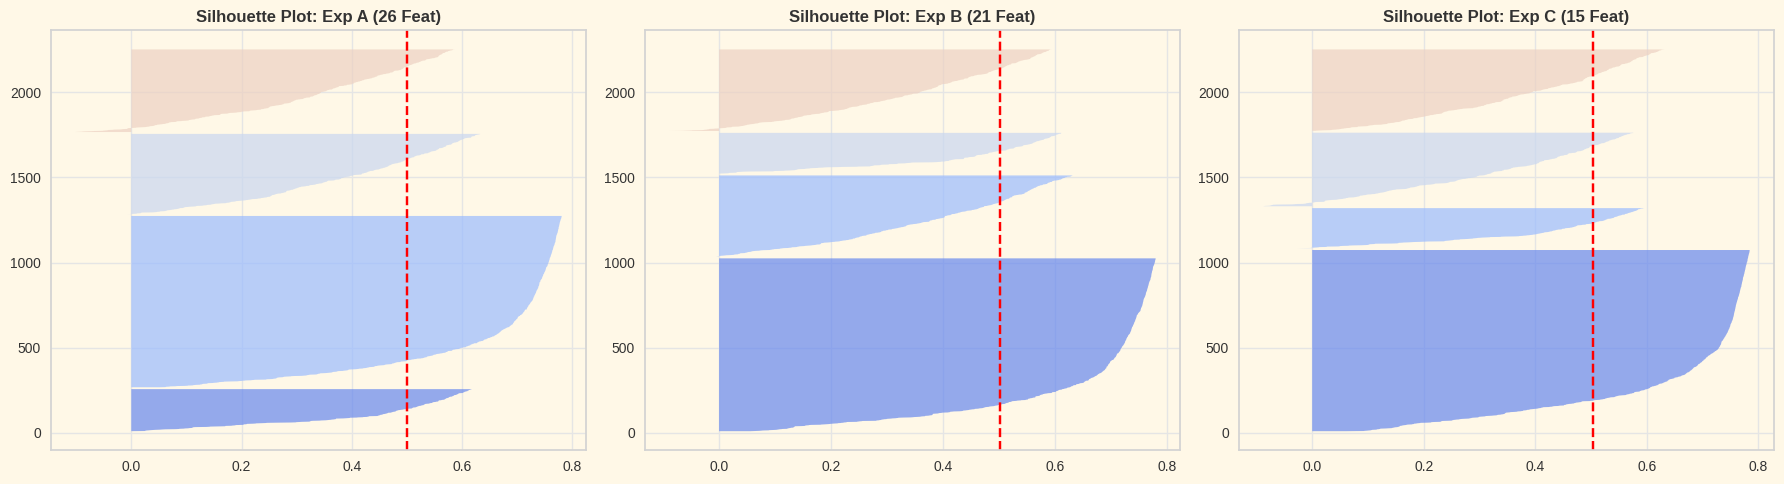

In [ ]:
# --- 7.2 Visual Comparison Dashboard Functions ---

def plot_pca_comparison(exp_results):
    """Visualisasi Perbandingan Separasi Klaster (PCA 2D)"""
    print("\n[Visualisasi A] Perbandingan Separasi Klaster (PCA 2D)")
    num_exps = len(exp_results)
    fig, axes = plt.subplots(1, num_exps, figsize=(6*num_exps, 5))
    for i, res in enumerate(exp_results):
        sns.scatterplot(x=res['X_pca'][:, 0], y=res['X_pca'][:, 1], hue=res['labels'], palette='tab10', ax=axes[i], alpha=0.6)
        axes[i].set_title(f"PCA Plot: {res['name']}\nSil: {res['silhouette']:.4f}", fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_silhouette_comparison(exp_results):
    """Visualisasi Perbandingan Kepadatan & Batas Klaster (Silhouette)"""
    print("\n[Visualisasi B] Perbandingan Kepadatan & Batas Klaster (Silhouette)")
    num_exps = len(exp_results)
    fig, axes = plt.subplots(1, num_exps, figsize=(6*num_exps, 5))
    for i, res in enumerate(exp_results):
        sample_sil_values = silhouette_samples(res['X_pca'], res['labels'])
        y_lower = 10
        for j in range(K_FINAL):
            ith_cluster_sil_values = sample_sil_values[res['labels'] == j]
            ith_cluster_sil_values.sort()
            axes_sil_i = axes[i]
            axes_sil_i.fill_betweenx(np.arange(y_lower, y_lower + len(ith_cluster_sil_values)), 0, ith_cluster_sil_values, alpha=0.7)
            y_lower += len(ith_cluster_sil_values) + 10
        axes[i].axvline(x=res['silhouette'], color="red", linestyle="--")
        axes[i].set_title(f"Silhouette Plot: {res['name']}", fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_snake_comparison(exp_results):
    """Visualisasi Perbandingan DNA Perilaku (Snake Plot Full Features)"""
    print("\n[Visualisasi C] Perbandingan DNA Perilaku (Snake Plot Full Features)")
    for res in exp_results:
        plt.figure(figsize=(15, 6))
        current_features = res['features']
        df_snake = X_scaled_full[current_features].copy()
        df_snake['Cluster'] = res['labels']
        df_melt = pd.melt(df_snake, id_vars=['Cluster'], value_vars=current_features)

        sns.lineplot(data=df_melt, x='variable', y='value', hue='Cluster', marker='o', palette='tab10', ci=None)
        plt.axhline(0, color='black', linestyle='--', alpha=0.3)
        plt.title(f"Snake Plot: {res['name']} (Full Features)", fontweight='bold', fontsize=14)
        plt.xticks(rotation=90)
        plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.grid(axis='y', alpha=0.2)
        plt.show()

# Jalankan Visualisasi Secara Terpisah
plot_pca_comparison(results)
plot_silhouette_comparison(results)



[Visualisasi C] Perbandingan DNA Perilaku (Snake Plot Full Features)


/tmp/ipykernel_162/4268350272.py:43: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df_melt, x='variable', y='value', hue='Cluster', marker='o', palette='tab10', ci=None)


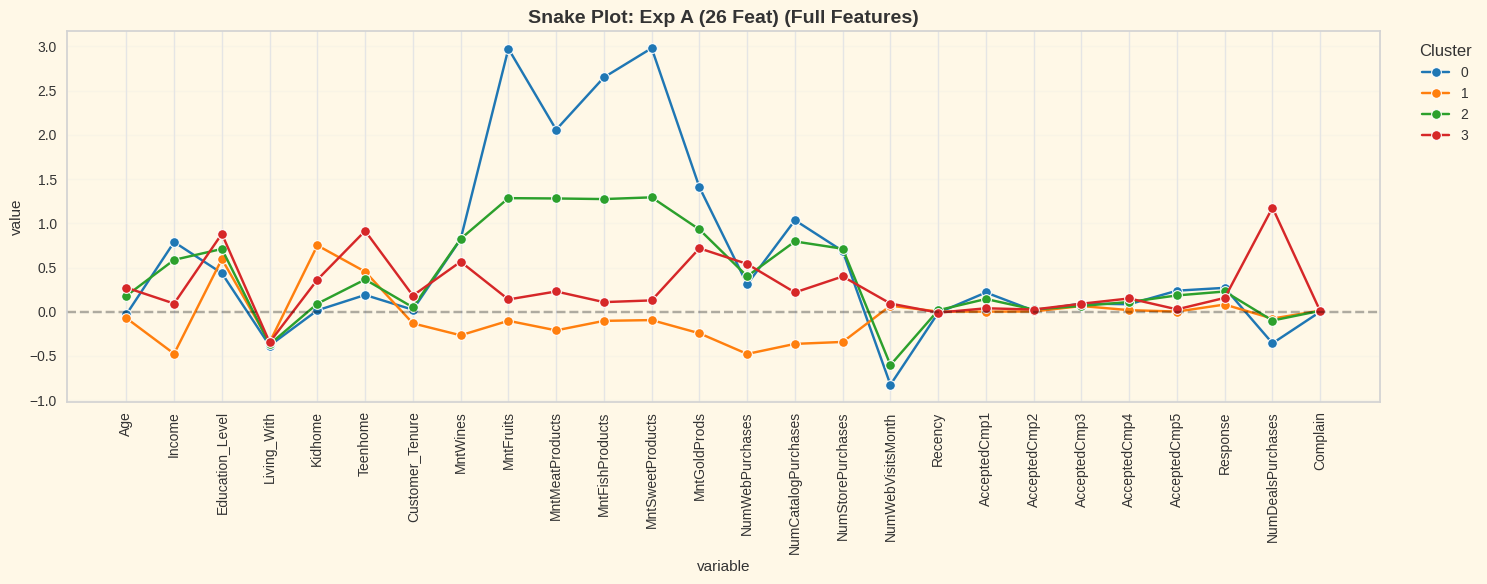

/tmp/ipykernel_162/4268350272.py:43: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df_melt, x='variable', y='value', hue='Cluster', marker='o', palette='tab10', ci=None)


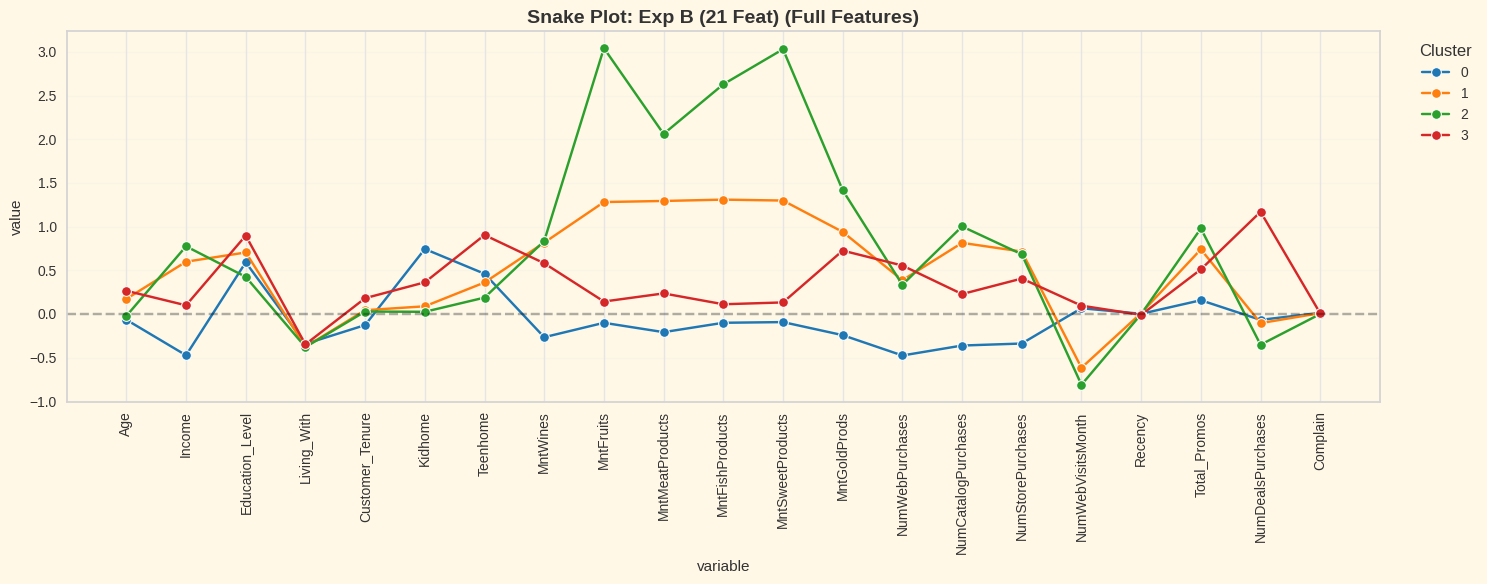

/tmp/ipykernel_162/4268350272.py:43: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df_melt, x='variable', y='value', hue='Cluster', marker='o', palette='tab10', ci=None)


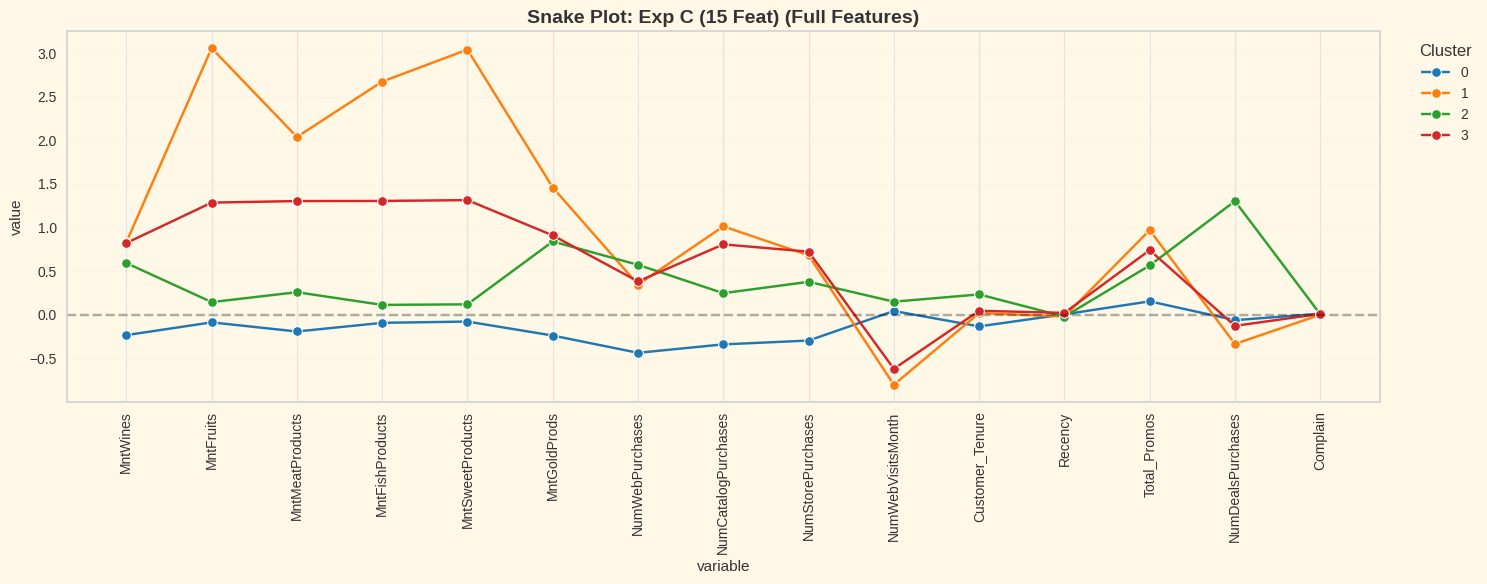

In [ ]:
plot_snake_comparison(results)

In [ ]:
from IPython.display import display, HTML
print(f"\n--- Mean Cluster Profile Comparison [A] [B] [C] ---")

# CSS tambahan untuk memperbesar sel tabel (padding) agar heatmap terlihat lebih luas
table_style = """
<style>
    .large-heatmap th, .large-heatmap td {
        padding: 8px 12px !important;
        text-align: center !important;
    }
    .large-heatmap caption {
        font-size: 16px !important;
        padding: 10px !important;
    }
</style>
"""

html_str = table_style
for res in results:
    df_temp = df_prep.copy()
    df_temp['Cluster'] = res['labels']
    scenario_features = res['features']

    # Menghitung rata-rata per klaster
    profile_mean = df_temp.groupby('Cluster')[scenario_features].mean().round(2)

    # Konversi Styler ke HTML dengan Background Gradient per Baris
    # Ukuran font ditingkatkan ke 14px untuk keterbacaan yang lebih baik
    styled_html = (profile_mean.T.style
                   .background_gradient(cmap='YlGnBu', axis=1)
                   .format("{:.2f}")
                   .set_table_attributes("class='large-heatmap' style='display:inline-table; margin-right:40px; border:1px solid #ccc; font-size:14px;'")
                   .set_caption(f"<b>{res['name']}</b>")
                   .to_html())

    html_str += styled_html

# Tampilkan seluruh tabel dalam satu baris HTML dengan scroll horizontal jika perlu
display(HTML(f"<div style='white-space: nowrap; overflow-x: auto; padding: 15px; background-color: #FFF8E7;'>{html_str}</div>"))


--- Mean Cluster Profile Comparison [A] [B] [C] ---


Cluster,0,1,2,3
Age,43.46,42.71,47.24,48.90
Income,77554.52,35581.68,70860.19,54442.89
Education_Level,1.44,1.59,1.71,1.88
Living_With,0.62,0.65,0.63,0.65
Kidhome,0.02,0.75,0.09,0.36
Teenhome,0.19,0.45,0.36,0.91
Customer_Tenure,363.83,310.12,373.37,419.63
MntWines,569.45,46.93,571.12,447.05
MntFruits,100.17,4.83,47.81,12.31
MntMeatProducts,512.49,22.48,344.56,117.50


In [ ]:
# --- 7.1 Experiment Metrics Comparison ---
metrics_df = pd.DataFrame([
    {
        'Experiment': r['name'],
        'N Features': len(r['features']),
        'Silhouette Score': round(r['silhouette'], 4),
        'Davies-Bouldin Index': round(r['dbi'], 4)
    }
    for r in results
])

# print("\n--- Experiment Metrics Comparison ---")
display(metrics_df)




,Experiment,N Features,Silhouette Score,Davies-Bouldin Index
0,Exp A (26 Feat),26,0.5001,0.7728
1,Exp B (21 Feat),21,0.5012,0.7714
2,Exp C (15 Feat),15,0.5031,0.7907


### **Model Selection & Justification**

Setelah mengevaluasi tiga skenario eksperimen, **Experiment B (Balanced - 21 Features)** dipilih sebagai yang terbaik karena berhasil menyeimbangkan antara akurasi statistik dan relevansi serta kemudahan interpretasi bisnis.

Experiment C dianggap terlalu reduktif karena menghapus variabel demografi dan justru malah membuat skor DBI lebih buruk dari pada lainnya. Hal ini mengindikasikan bahwa tanpa konteks demografi, batas antar klaster menjadi lebih kabur dan terjadi tumpang tindih (overlap) antar segmen.

Di sisi lain, hasil statistik 21 fitur dengan 26 fitur memiliki perbedaan yang sangat kecil sehingga secara matematis keduanya dianggap setara.
Pada hasil dengan 26 fitur,seperti yang terlihat pada visualisasi, variabel individual promo/kampanye tidak terlalu memberikan kontribusi yang jelas dalam membedakan antar-klaster sehingga interpretasi variabel ini lebih sulit dijelaskan. sebaliknya, dengan mengagregasikannya menjadi total promo, perbedaan antara variabel total promo antar-klaster lebih jelas sehingga lebih mudah diinterpretasikan dan diimplementasikan ke dalam strategi pemasaran.

Pada dunia nyata sering kali pemilihan clustering bersifat subjektif, dimana Statistik, kebutuhan bisnis hingga pengalaman atau domain knowledge sangat berpengaruh terhadap keputusan. Menemukan trade-off yang tepat antara kekuatan statistik dan kebutuhan bisnis sering kali mengonsumsi energi yang lebih besar dari yang diperkirakan,ini sangat penting agar cluster yang dihasilkan tidak hanya bagus secara statistik, tetapi juga benar-benar menyelesaikan masalah bisnis yang ada.




> *"Clustering is in the eye of the beholder."*  
> — Vladimir Estivill-Castro (2002)  

> *"Far better an approximate answer to the right question, which is often vague, than an exact answer to the wrong question, which can always be made precise."*  
> — John W. Tukey (1962)





# **5. Cluster Profiling**

In [ ]:
# Set visual theme agar konsisten dengan Executive Dashboard
plt.rcParams.update({'figure.facecolor': '#FFF8E7', 'axes.facecolor': '#FFF8E7'})
sns.set_palette("tab10")

K_FINAL = 4
# Prepare data for profiling
# 1. Identify the results for 'Exp B (21 Feat)'
exp_B_result = next(res for res in results if res['name'] == 'Exp B (21 Feat)')

# 2. Extract features and labels for Experiment B
features_for_profiling = exp_B_result['features']
cluster_labels_B = exp_B_result['labels']

# 3. Create df_profile_B from df_prep with selected features
df_profile_B = df_prep[features_for_profiling].copy()

# 4. Add 'Cluster' column to df_profile_B
df_profile_B['Cluster'] = cluster_labels_B

# 5. Memasukkan fitur deskriptor asli yang dibutuhkan untuk profiling namun tidak ada di 21 fitur model
cols_to_add = ['Total_Spent', 'Total_Children', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
for col in cols_to_add:
    if col not in df_profile_B.columns:
        df_profile_B[col] = df_prep[col]

print("df_profile_B created with selected features and cluster labels for Experiment B.")
display(df_profile_B.head())

df_profile_B created with selected features and cluster labels for Experiment B.


,Age,Income,Education_Level,Living_With,Customer_Tenure,Kidhome,Teenhome,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Recency,Total_Promos,NumDealsPurchases,Complain,Cluster,Total_Spent,Total_Children,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response
0,57,58138.0,1,0,663,0,0,635,88,546,172,88,88,8,10,4,7,58,1,3,0,2,1617,0,0,0,0,0,0,1
1,60,46344.0,1,0,113,1,1,11,1,6,2,1,6,1,1,2,5,38,0,2,0,0,27,2,0,0,0,0,0,0
2,49,71613.0,1,1,312,0,0,426,49,127,111,21,42,8,2,10,4,26,0,1,0,1,776,0,0,0,0,0,0,0
3,30,26646.0,1,1,139,1,0,11,4,20,10,3,5,2,0,4,6,26,0,2,0,0,53,1,0,0,0,0,0,0
4,33,58293.0,3,1,161,1,0,173,43,118,46,27,15,5,3,6,5,94,0,5,0,3,422,1,0,0,0,0,0,0



--- Overview: Mean Cluster Profile for Experiment B (Per-Feature Graded) ---


Cluster,0,1,2,3
Age,42.81,47.10,43.59,48.78
Income,35654.67,71267.34,77132.05,54662.86
Education_Level,1.59,1.70,1.42,1.90
Living_With,0.66,0.62,0.62,0.65
Customer_Tenure,311.65,371.15,365.83,419.20
Kidhome,0.74,0.09,0.02,0.36
Teenhome,0.46,0.36,0.19,0.90
MntWines,47.10,567.96,576.83,454.37
MntFruits,4.87,47.73,102.35,12.42
MntMeatProducts,23.08,347.53,513.30,118.88



--- Overview: Snake Plot for Experiment B ---


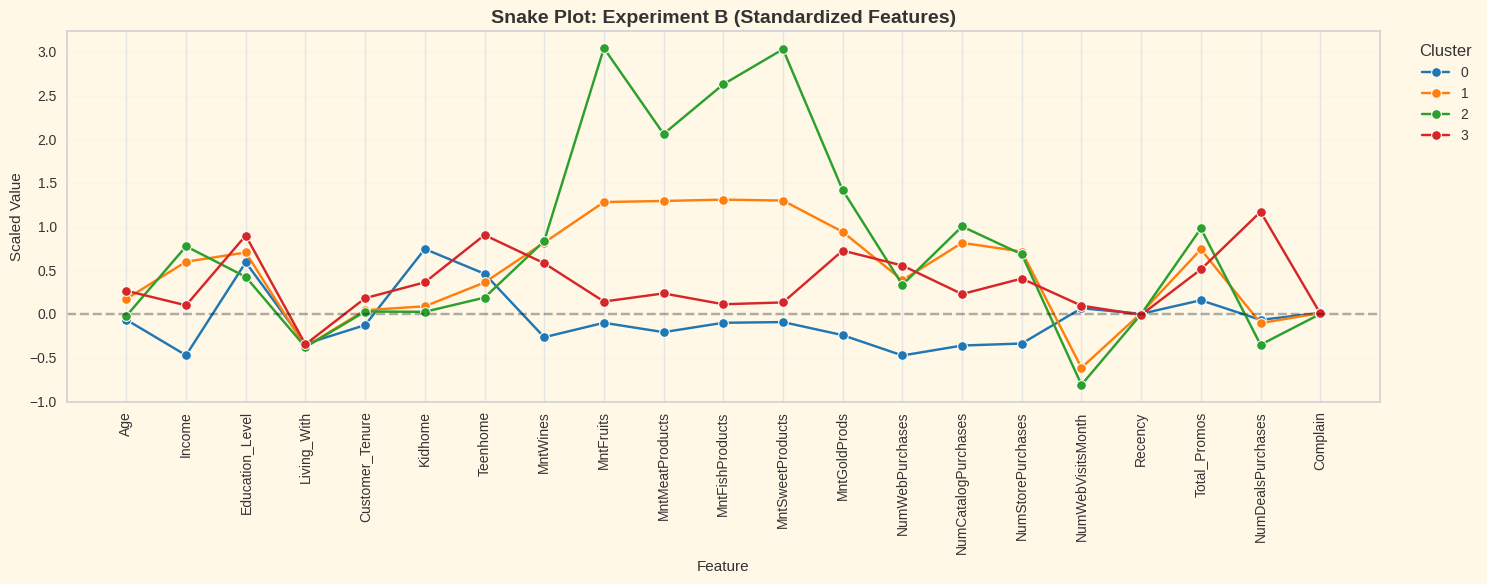

In [ ]:

# OVERVIEW VISUALIZATION FOR EXPERIMENT B (21 Features)


print("\n--- Overview: Mean Cluster Profile for Experiment B (Per-Feature Graded) ---")
# Calculate mean values for each cluster
cluster_mean_profile = df_profile_B.groupby('Cluster')[exp_B_result['features']].mean().round(2)

# Apply per-feature grading using pandas styling
styled_mean_profile = (cluster_mean_profile.T.style
                       .background_gradient(cmap='YlGnBu', axis=1)
                       .format("{:.2f}")
                       .set_table_attributes("style='display:inline-table; margin-right:40px; border:1px solid #ccc; font-size:14px;'\n")
                       .set_caption("Mean Feature Values per Cluster (Experiment B) - Per-Feature Graded"))

display(styled_mean_profile)

print("\n--- Overview: Snake Plot for Experiment B ---")
# Prepare data for the snake plot using the scaled features from X_scaled_full
current_features_for_snake = exp_B_result['features']
df_snake_b = X_scaled_full[current_features_for_snake].copy()
df_snake_b['Cluster'] = exp_B_result['labels']
df_melt_b = pd.melt(df_snake_b, id_vars=['Cluster'], value_vars=current_features_for_snake)

# Generate the snake plot
plt.figure(figsize=(15, 6))
sns.lineplot(data=df_melt_b, x='variable', y='value', hue='Cluster', marker='o', palette='tab10', errorbar=None)
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.title("Snake Plot: Experiment B (Standardized Features)", fontweight='bold', fontsize=14)
plt.xlabel("Feature")
plt.ylabel("Scaled Value")
plt.xticks(rotation=90)
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

Memulai Profiling untuk 4 Segmen Pelanggan...


/tmp/ipykernel_162/4289285139.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_sizes.index, y=cluster_sizes.values, palette='viridis')


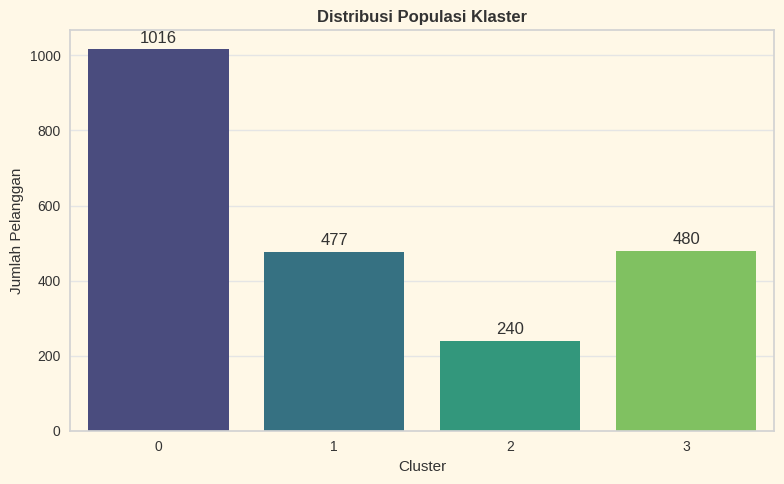

In [ ]:
print("Memulai Profiling untuk 4 Segmen Pelanggan...")

# Menyimpan ukuran cluster untuk konteks populasi
cluster_sizes = df_profile_B['Cluster'].value_counts().sort_index()

# Visualisasi distribusi populasi klaster
plt.figure(figsize=(8, 5))
sns.barplot(x=cluster_sizes.index, y=cluster_sizes.values, palette='viridis')
plt.title("Distribusi Populasi Klaster", fontweight='bold')
plt.xlabel("Cluster")
plt.ylabel("Jumlah Pelanggan")
for index, value in enumerate(cluster_sizes.values):
    plt.text(index, value + 10, str(value), ha='center', va='bottom')
plt.tight_layout()
plt.show()

## 5.1 Demographic Profile


--- 6.1 Demographic Profile: Social-Economic Vitals ---


/tmp/ipykernel_162/4094448345.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_profile_B, x='Cluster', y='Income', palette='tab10', ax=axes[0])
/tmp/ipykernel_162/4094448345.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df_profile_B, x='Cluster', y='Customer_Tenure', palette='tab10', ax=axes[2])


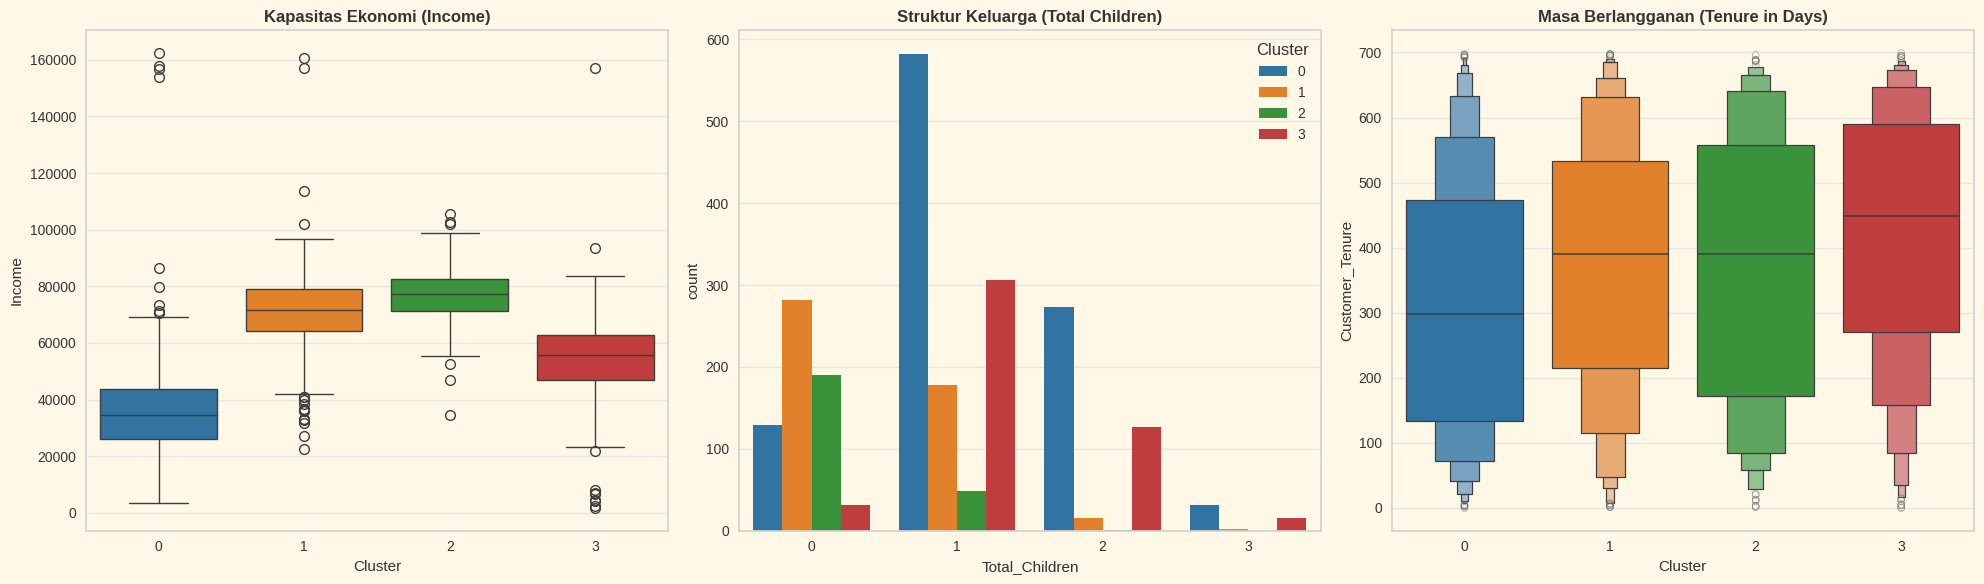


--- 6.1.1 Social Composition: Education & Living Status ---


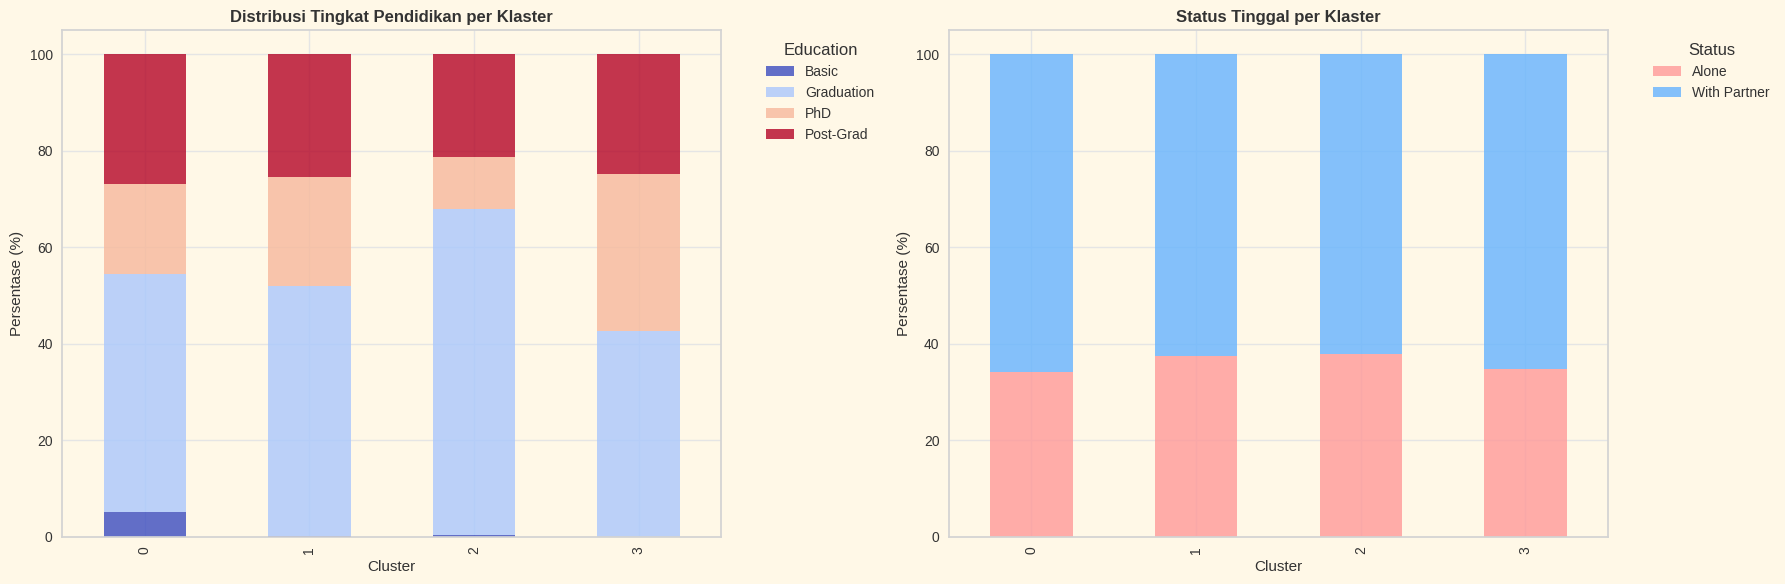


--- 6.1.2 Demographic Deep Dive: Age vs Income Joint Analysis ---


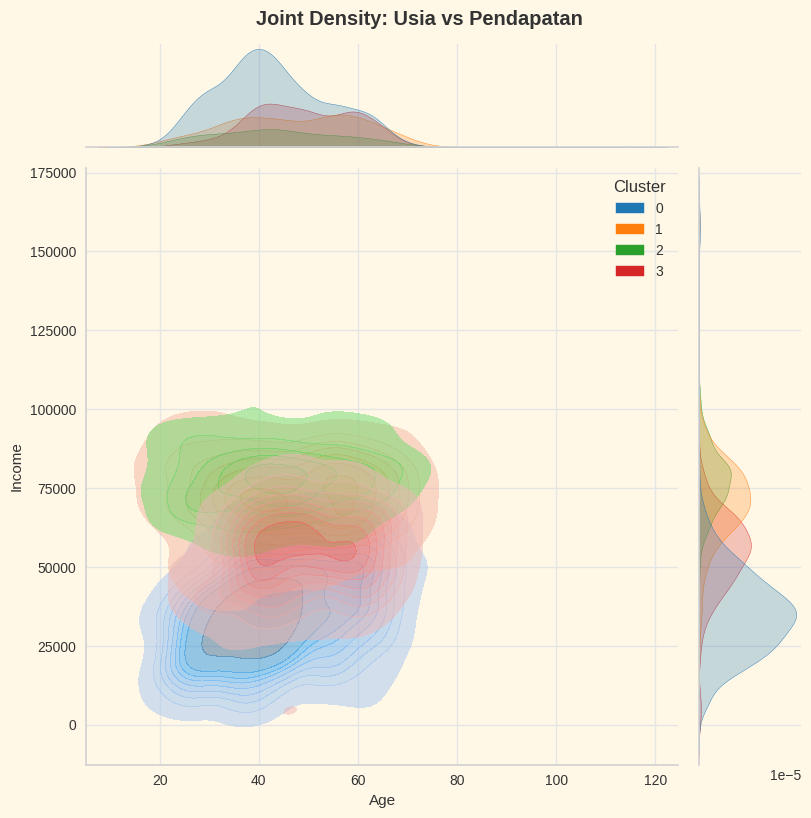

In [ ]:
# DEMOGRAPHIC PROFILE
# Menjawab: Siapa mereka secara sosial-ekonomi dan fase kehidupan?

print("\n--- 6.1 Demographic Profile: Social-Economic Vitals ---")

# --- BAGIAN A: DISTRIBUSI DASAR (VITALS) ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Income Distribution (Kapasitas Ekonomi)
sns.boxplot(data=df_profile_B, x='Cluster', y='Income', palette='tab10', ax=axes[0])
axes[0].set_title("Kapasitas Ekonomi (Income)", fontweight='bold')

# 2. Total Children (Struktur Rumah Tangga)
sns.countplot(data=df_profile_B, x='Total_Children', hue='Cluster', palette='tab10', ax=axes[1])
axes[1].set_title("Struktur Keluarga (Total Children)", fontweight='bold')
axes[1].legend(title='Cluster', loc='upper right')

# 3. Customer Tenure (Loyalitas Waktu)
sns.boxenplot(data=df_profile_B, x='Cluster', y='Customer_Tenure', palette='tab10', ax=axes[2])
axes[2].set_title("Masa Berlangganan (Tenure in Days)", fontweight='bold')

plt.tight_layout()
plt.show()

# --- BAGIAN B: KOMPOSISI SOSIAL (STACKED ANALYSIS) ---
print("\n--- 6.1.1 Social Composition: Education & Living Status ---")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# 1. Education Level Composition
# 0:Basic, 1:Graduation, 2:Master/2n Cycle, 3:PhD
edu_map = {0:'Basic', 1:'Graduation', 2:'Post-Grad', 3:'PhD'}
df_temp_edu = df_profile_B.copy()
df_temp_edu['Education_Label'] = df_temp_edu['Education_Level'].map(edu_map)
edu_comp = pd.crosstab(df_temp_edu['Cluster'], df_temp_edu['Education_Label'], normalize='index') * 100
edu_comp.plot(kind='bar', stacked=True, ax=ax1, colormap='coolwarm', alpha=0.8)
ax1.set_title("Distribusi Tingkat Pendidikan per Klaster", fontweight='bold')
ax1.set_ylabel("Persentase (%)")
ax1.legend(title='Education', bbox_to_anchor=(1.05, 1))

# 2. Living Status (Partnered vs Single)
living_map = {1:'With Partner', 0:'Alone'}
df_temp_living = df_profile_B.copy()
df_temp_living['Living_Status'] = df_temp_living['Living_With'].map(living_map)
living_comp = pd.crosstab(df_temp_living['Cluster'], df_temp_living['Living_Status'], normalize='index') * 100
living_comp.plot(kind='bar', stacked=True, ax=ax2, color=['#FF9999','#66B3FF'], alpha=0.8)
ax2.set_title("Status Tinggal per Klaster", fontweight='bold')
ax2.set_ylabel("Persentase (%)")
ax2.legend(title='Status', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

# --- BAGIAN C: JOIN PLOT (THE DENSITY MAP) ---
# Join Plot sangat kuat untuk melihat area "Overlap" dan "Separation" antar klaster
# pada dua dimensi demografi paling krusial.
print("\n--- 6.1.2 Demographic Deep Dive: Age vs Income Joint Analysis ---")
j = sns.jointplot(data=df_profile_B, x='Age', y='Income', hue='Cluster',
                  palette='tab10', kind='kde', fill=True, alpha=0.5, height=8)
j.fig.suptitle("Joint Density: Usia vs Pendapatan", fontweight='bold', y=1.02)
plt.show()


## 5.2 Spending Behaviour


--- 6.2 Spending Behaviour: Preferensi Kategori Produk ---


/tmp/ipykernel_162/440866943.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_profile_B, x='Cluster', y='Total_Spent', palette='viridis', ax=axes[0], errorbar=None)


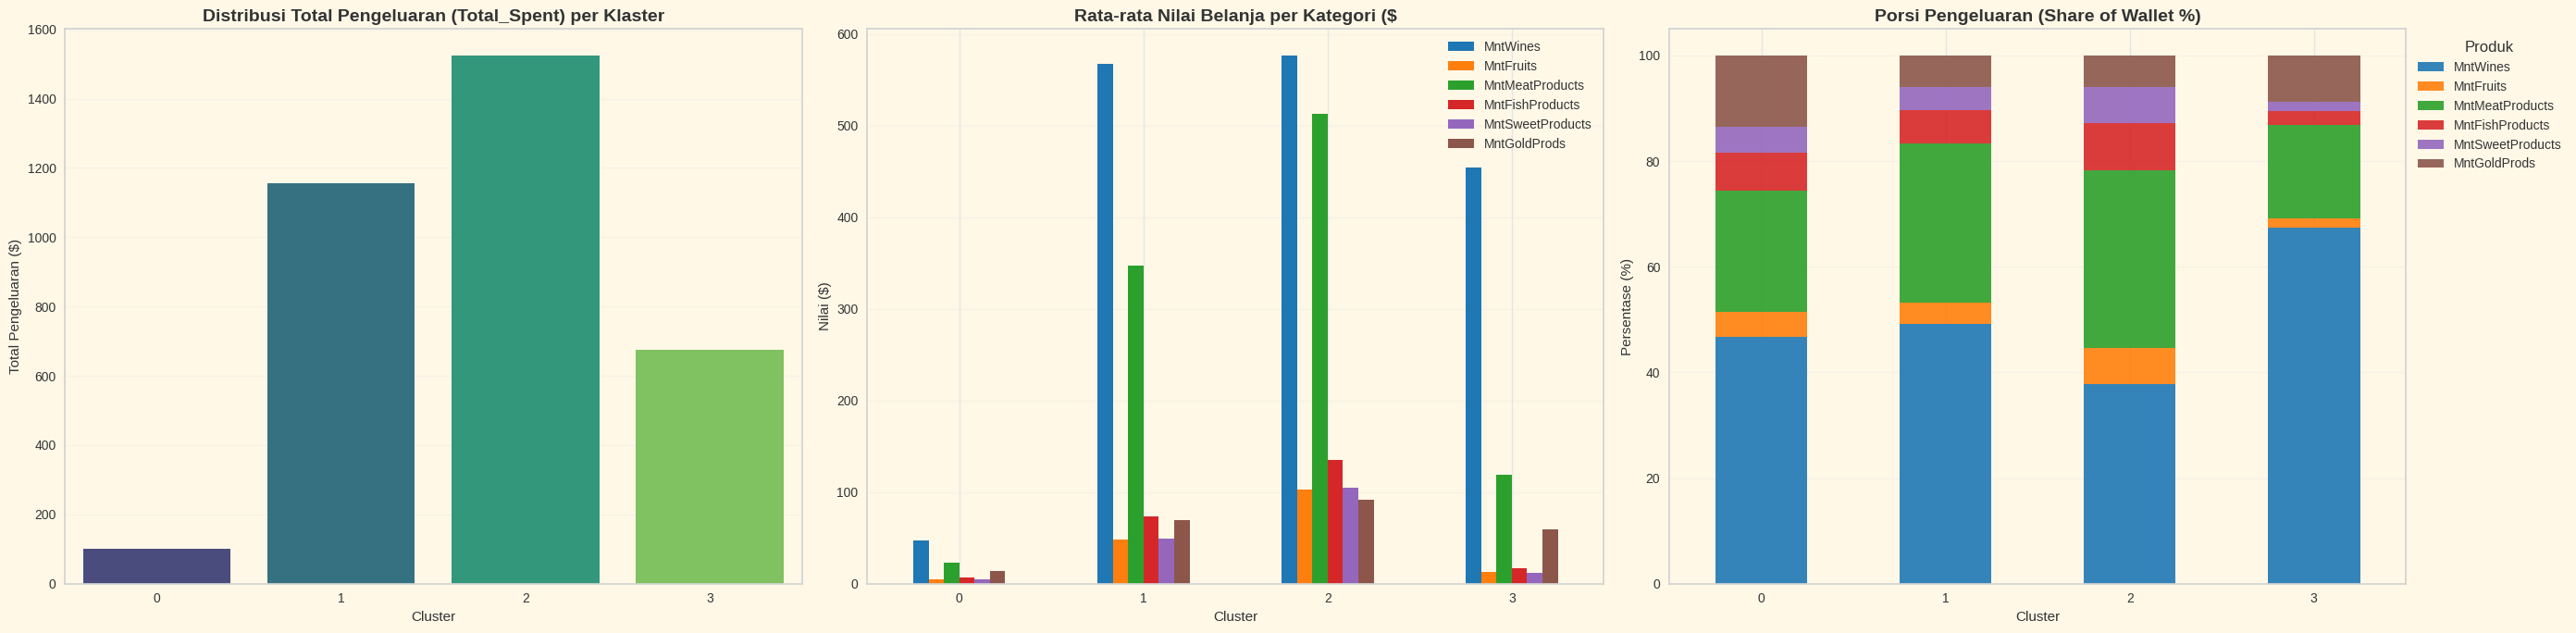

In [ ]:
# 6.2 SPENDING BEHAVIOUR (What do they value?)
# Tujuan: Mengetahui 'Product DNA' tiap klaster untuk strategi Cross-selling.
print("\n--- 6.2 Spending Behaviour: Preferensi Kategori Produk ---")

mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df_spend = df_profile_B.groupby('Cluster')[mnt_cols].mean()

# Visualisasi: Stacked Bar untuk melihat 'Share of Wallet'
df_spend_pct = df_spend.div(df_spend.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 3, figsize=(28, 7)) # Increased subplot count to 3

# 1. Total Spent Distribution (Overall Spending) - now at axes[0]
sns.barplot(data=df_profile_B, x='Cluster', y='Total_Spent', palette='viridis', ax=axes[0], errorbar=None)
axes[0].set_title("Distribusi Total Pengeluaran (Total_Spent) per Klaster", fontweight='bold', fontsize=14)
axes[0].set_ylabel("Total Pengeluaran ($)")
axes[0].set_xlabel("Cluster")
axes[0].grid(axis='y', alpha=0.3)

# 2. Absolute Spending (Nilai Dolar) - now at axes[1]
df_spend.plot(kind='bar', ax=axes[1])
axes[1].set_title("Rata-rata Nilai Belanja per Kategori ($", fontweight='bold', fontsize=14)
axes[1].set_ylabel("Nilai ($)")
axes[1].set_xlabel("Cluster")
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)

# 3. Relative Spending (Porsi Keranjang Belanja) - now at axes[2]
df_spend_pct.plot(kind='bar', stacked=True, ax=axes[2], alpha=0.9)
axes[2].set_title("Porsi Pengeluaran (Share of Wallet %)", fontweight='bold', fontsize=14)
axes[2].set_ylabel("Persentase (%)")
axes[2].set_xlabel("Cluster")
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(bbox_to_anchor=(1, 1), title="Produk")
axes[2].grid(axis='y', alpha=0.3)


plt.tight_layout()
plt.show()

## 5.3 Promotion Response


--- 6.3 Promotion Response: Sensitivitas Diskon & Kampanye ---


/tmp/ipykernel_162/1071996235.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_profile_B, x='Cluster', y='NumDealsPurchases', palette='tab10', ax=ax3)
/tmp/ipykernel_162/1071996235.py:38: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_profile_B, x='Cluster', y='Total_Promos', palette='tab10', ax=ax4, ci=None)
/tmp/ipykernel_162/1071996235.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_profile_B, x='Cluster', y='Total_Promos', palette='tab10', ax=ax4, ci=None)


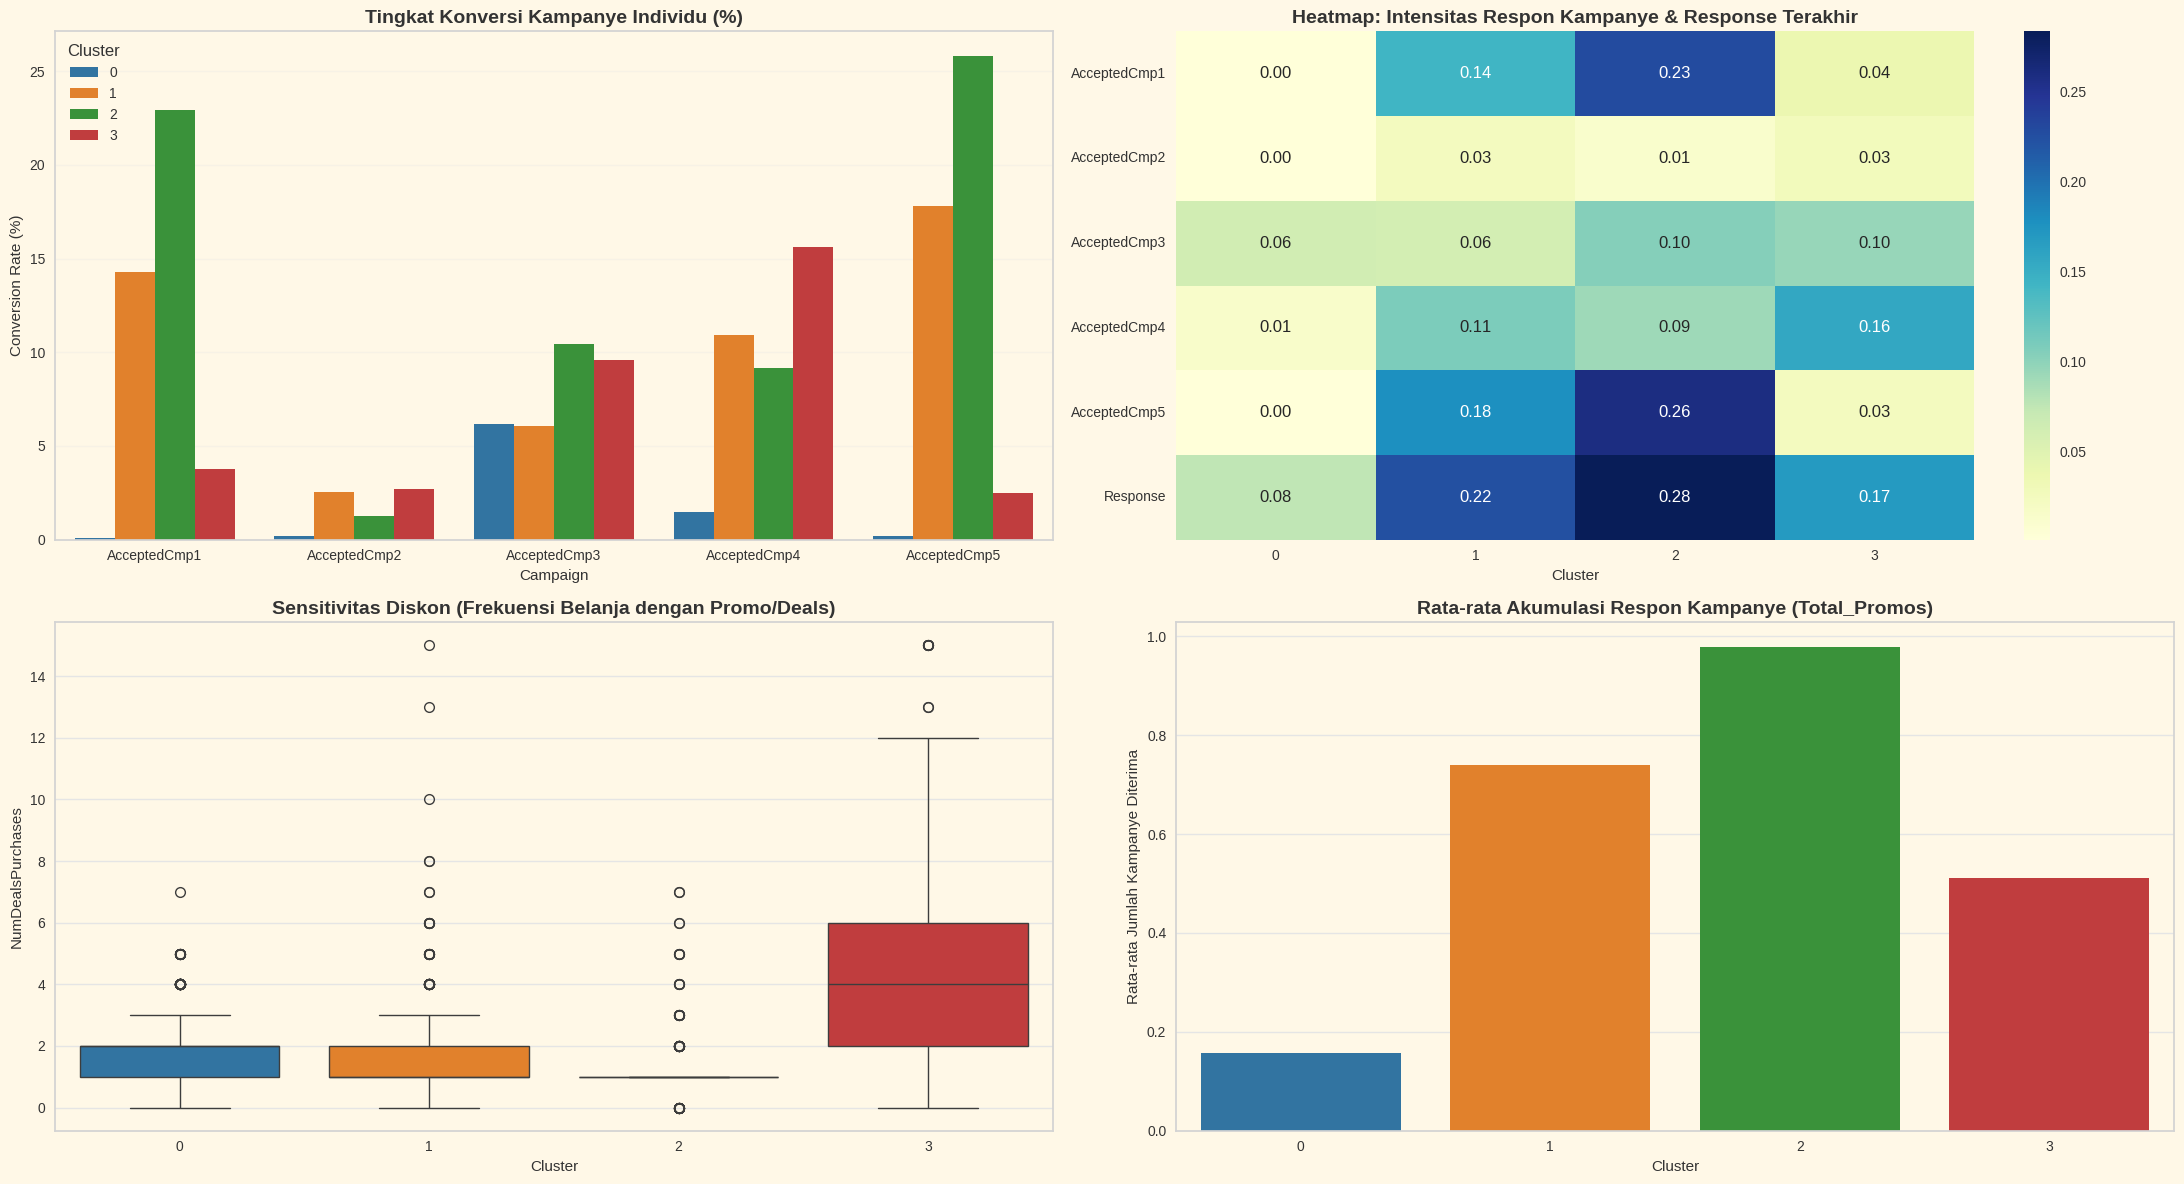

In [ ]:
# 6.3 PROMOTION RESPONSE (Marketing Sensitivity)
# Variabel: AcceptedCmp1-5, Response, Total_Promos, NumDealsPurchases.
# Metrik: Conversion Rate (Rata-rata respon biner), Mean (NumDeals).
# Tujuan: Mengukur efektivitas kampanye masa lalu dan sensitivitas terhadap diskon.
print("\n--- 6.3 Promotion Response: Sensitivitas Diskon & Kampanye ---")

# 1. Menghitung Conversion Rate (%) Kampanye 1-5
promo_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
promo_rates = (df_profile_B.groupby('Cluster')[promo_cols].mean() * 100).round(2)
promo_melted = promo_rates.reset_index().melt(id_vars='Cluster', var_name='Campaign', value_name='ConversionRate')

# 2. Menyiapkan visualisasi terpadu
fig = plt.figure(figsize=(22, 12))
gs = fig.add_gridspec(2, 2)

# A. Multi-bar Chart: Success Rate tiap Kampanye per Klaster
ax1 = fig.add_subplot(gs[0, 0])
sns.barplot(data=promo_melted, x='Campaign', y='ConversionRate', hue='Cluster', palette='tab10', ax=ax1)
ax1.set_title("Tingkat Konversi Kampanye Individu (%)", fontweight='bold', fontsize=14)
ax1.set_ylabel("Conversion Rate (%)")
ax1.grid(axis='y', alpha=0.3)

# B. Heatmap: Intensitas Respon Promo & Response Terakhir
ax2 = fig.add_subplot(gs[0, 1])
# Kita tambahkan Response dan Total_Promos untuk heatmap intensitas
all_promo_vars = promo_cols + ['Response']
intensity_data = df_profile_B.groupby('Cluster')[all_promo_vars].mean()
sns.heatmap(intensity_data.T, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax2)
ax2.set_title("Heatmap: Intensitas Respon Kampanye & Response Terakhir", fontweight='bold', fontsize=14)

# C. Sensitivitas Diskon (NumDealsPurchases)
ax3 = fig.add_subplot(gs[1, 0])
sns.boxplot(data=df_profile_B, x='Cluster', y='NumDealsPurchases', palette='tab10', ax=ax3)
ax3.set_title("Sensitivitas Diskon (Frekuensi Belanja dengan Promo/Deals)", fontweight='bold', fontsize=14)

# D. Akumulasi Respon (Total_Promos)
ax4 = fig.add_subplot(gs[1, 1])
sns.barplot(data=df_profile_B, x='Cluster', y='Total_Promos', palette='tab10', ax=ax4, ci=None)
ax4.set_title("Rata-rata Akumulasi Respon Kampanye (Total_Promos)", fontweight='bold', fontsize=14)
ax4.set_ylabel("Rata-rata Jumlah Kampanye Diterima")

plt.tight_layout()
plt.show()

## 5.1 Channel Preference


--- 6.4 Channel Preference: Jalur Transaksi Utama ---


/tmp/ipykernel_162/2177054651.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_visit.reset_index(), x='Cluster', y='NumWebVisitsMonth', palette='Set2', ax=ax2)


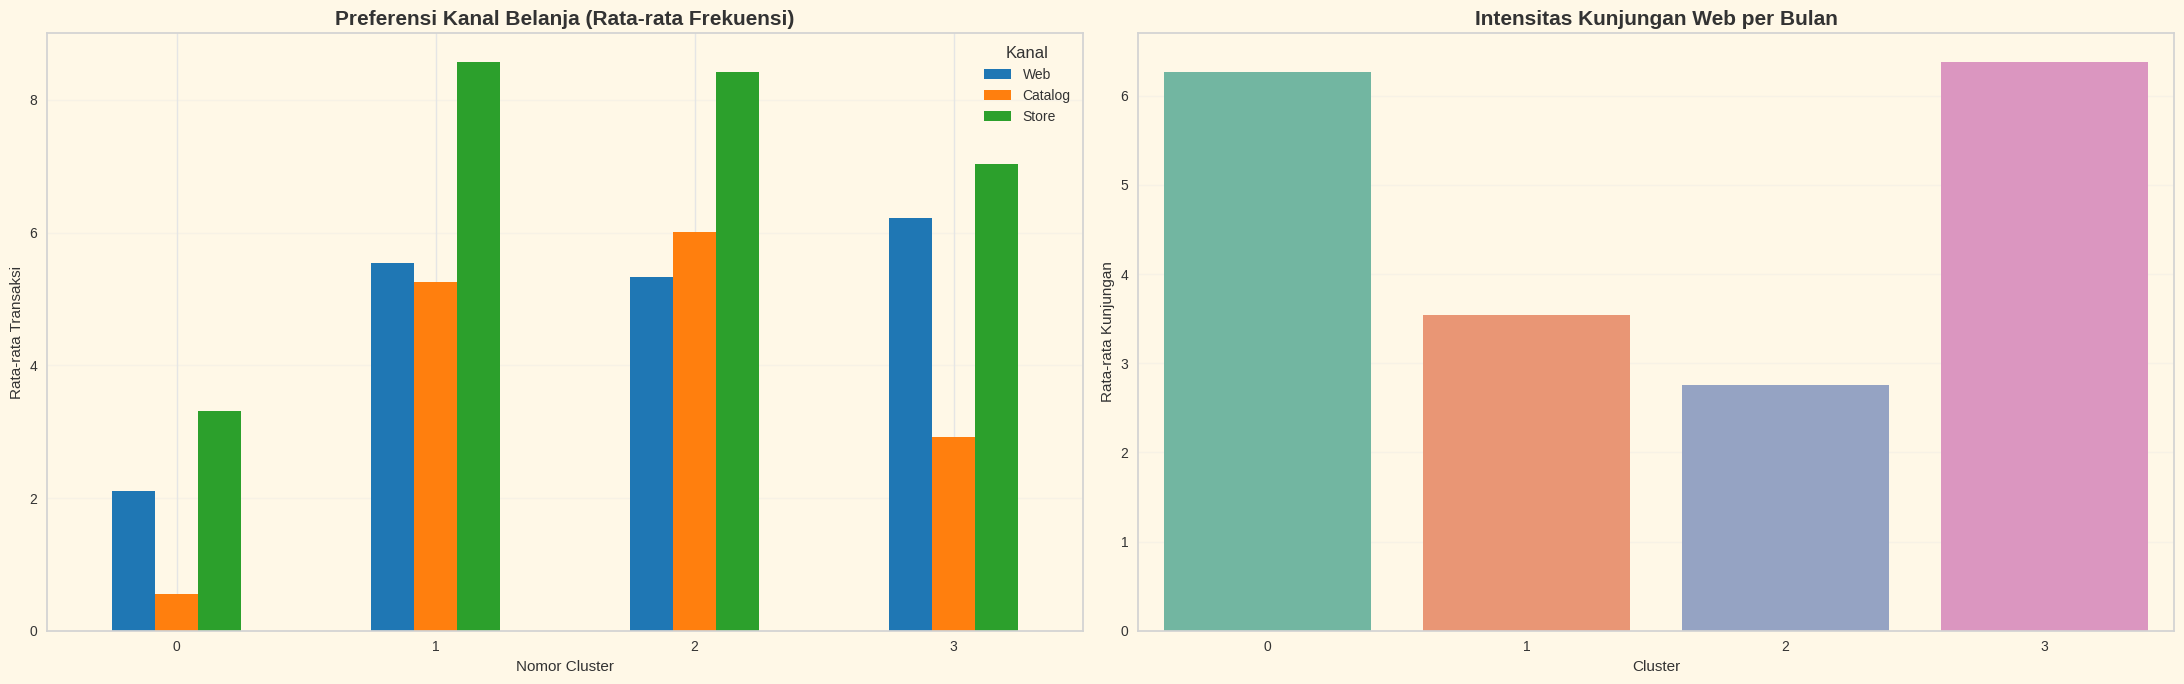


--- Joint Plot: Pembelian Web vs Kunjungan Web ---


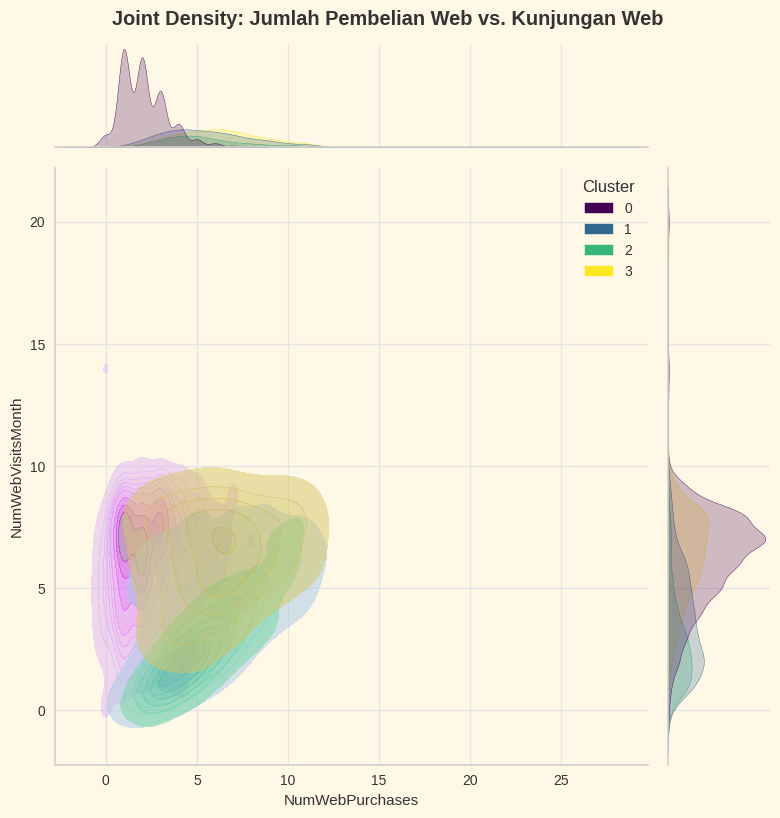

In [ ]:
# ==============================================================================
# 6.4 CHANNEL PREFERENCE (Where to meet them?)
# ==============================================================================
# Variabel: NumWebPurchases, NumCatalogPurchases, NumStorePurchases, NumWebVisitsMonth.
# Metrik: Mean Frequency.
# Tujuan: Menentukan touchpoint terbaik untuk pengiriman pesan marketing.

print("\n--- 6.4 Channel Preference: Jalur Transaksi Utama ---")

# 1. Analisis Kanal Transaksi (Buying Channels)
channel_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df_chan = df_profile_B.groupby('Cluster')[channel_cols].mean()

# 2. Analisis Intensitas Kunjungan (Browsing/Engagement)
df_visit = df_profile_B.groupby('Cluster')[['NumWebVisitsMonth']].mean()

# Visualisasi Berdampingan
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 7))

# A. Grouped Bar: Preferensi Kanal (Web vs Catalog vs Store)
df_chan.plot(kind='bar', ax=ax1)
ax1.set_title("Preferensi Kanal Belanja (Rata-rata Frekuensi)", fontweight='bold', fontsize=15)
ax1.set_ylabel("Rata-rata Transaksi")
ax1.set_xlabel("Nomor Cluster")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
ax1.grid(axis='y', alpha=0.3)
ax1.legend(title="Kanal", labels=['Web', 'Catalog', 'Store'])

# B. Bar Chart: Intensitas Kunjungan Web (Engagement Touchpoint)
sns.barplot(data=df_visit.reset_index(), x='Cluster', y='NumWebVisitsMonth', palette='Set2', ax=ax2)
ax2.set_title("Intensitas Kunjungan Web per Bulan", fontweight='bold', fontsize=15)
ax2.set_ylabel("Rata-rata Kunjungan")
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# C. Joint Plot: NumWebPurchases vs NumWebVisitsMonth
print("\n--- Joint Plot: Pembelian Web vs Kunjungan Web ---")
j = sns.jointplot(data=df_profile_B, x='NumWebPurchases', y='NumWebVisitsMonth', hue='Cluster',
                  palette='viridis', kind='kde', fill=True, alpha=0.5, height=8)
j.fig.suptitle("Joint Density: Jumlah Pembelian Web vs. Kunjungan Web", fontweight='bold', y=1.02)
plt.show()

# **6. Business Insights & Recommendations**

## 6.1 Interpretation of Each Cluster


Berdasarkan profilling sebelumnya, berikut adalah profil persona untuk keempat kelompok pelanggan untuk menjawab siapa mereka, apa perilaku mereka, dan bagaimana cara menjangkau mereka.

---


**Cluster 0: Segmen Massa Berdaya Beli Rendah**

**Siapa Mereka?**  
Kelompok terbesar (1.016 orang) dengan pendapatan terendah (~$35k). Keluarga muda dengan banyak anak.

**Apa yang Mereka Beli?**  
Pengeluaran sangat minim, hanya membeli kebutuhan dasar dalam jumlah kecil.

**Bagaimana Respon Mereka?**  
Sangat sulit dikonversi. Hampir tidak pernah merespons kampanye promosi berbayar.

**Di Mana Menemui Mereka?**  
Di Website untuk riset. Kunjungan web mereka sangat tinggi namun jarang berakhir dengan transaksi (*The Browser Gap*).




---
**Cluster 1: Konsumen Premium Berbasis Toko Fisik**

**Siapa Mereka?**  
Kelompok mapan (477 orang) dengan pendapatan tinggi (~$71k). Pelanggan jangka panjang yang stabil.

**Apa yang Mereka Beli?**  
Pembelanja terbesar kedua dengan profil belanja paling merata di kategori sekunder (Emas, Ikan, Makanan Manis).

**Bagaimana Respon Mereka?**  
Target pemasaran ideal. Sangat reaktif dan responsif terhadap hampir semua jenis kampanye promosi.

**Di Mana Menemui Mereka?**  
Omnichannel. Aktif di Store, Katalog, dan Web. Mereka memiliki konversi web yang sangat efisien.

---

**Cluster 2: Konsumen Elit Bernilai Tinggi (Top Spenders)**

**Siapa Mereka?**  
Kelompok paling elit (240 orang) dengan pendapatan tertinggi (~$77k). Biasanya individu mapan tanpa beban anak di rumah.

**Apa yang mereka beli?**
Power spender yang memimpin di setiap kategori produk, terutama wine (~$576
) dan daging ($513)

**Bagaimana Respon Mereka?**  
Sangat selektif. Hanya merespons kampanye eksklusif (Cmp1/Cmp5) dan tidak terlalu tertarik pada diskon umum.

**Di Mana Menemui Mereka?**  
Di toko fisik (Store) atau melalui Katalog. Mereka adalah pembeli efisien dengan kunjungan web minimal.

---
**Cluster 3: Pelanggan Loyal Sensitif Harga**

**Siapa Mereka?**  
Pelanggan paling setia dengan masa berlangganan terlama (~419 hari). Umumnya keluarga dengan usia lebih senior.

**Apa yang Mereka Beli?**  
Fokus pada Wine dan Daging, namun dengan volume yang lebih moderat dibanding Sultan.

**Bagaimana Respon Mereka?**  
'Deal Hunters'. Sangat sensitif terhadap diskon dan paling sering menggunakan kupon (NumDealsPurchases).

**Di Mana Menemui Mereka?**  
Digital-first. Paling aktif melakukan pembelian melalui Web namun juga sering mengunjungi Store.

## 6.2 Strategic Marketing Implications & Recommended Business Actions

Berdasarkan hasil sebelumnya dari eksperimen yang terpilih, berikut adalah penerapan hasil atau insight dari clustering ke dalam strategi bisnis yang konkret.

---

**Cluster 0 — The Budget-Conscious Browsers (Mass Market)**

Strategic Marketing Implications

- **Conversion Gap**  
  Kelompok ini sering mengunjungi web (±6.26x) namun tingkat transaksinya sangat rendah. Hal ini mengindikasikan adanya hambatan harga atau ketidaksesuaian produk dengan daya beli mereka.

- **Low Priority for Paid Ads**  
  Dengan pendapatan relatif rendah dan respon promosi yang sangat kecil (≈0.16), investasi pada iklan berbayar berpotensi menghasilkan ROI yang rendah atau bahkan negatif.

Recommended Business Actions

1. **Entry-Level Product Focus**  
   Tawarkan produk esensial dengan harga ekonomis untuk memicu transaksi pertama.

2. **Low-Cost Engagement Automation**  
   Gunakan push notification atau email otomatis berbiaya rendah untuk mengirimkan konten edukasi produk, bukan iklan agresif.

3. **Flash Sales for Essentials**  
   Fokuskan promo pada kebutuhan pokok (*basic goods*) untuk menarik volume transaksi dari segmen mass market.

---

**Cluster 1 — The Traditional Affluents (Store Loyalists)**

Strategic Marketing Implications

- **Brick-and-Mortar Anchor**  
  Segmen ini merupakan penggerak utama trafik toko fisik (*Store Purchases tertinggi: ~8.57*). Kanal digital lebih berperan sebagai pendukung, bukan pendorong utama transaksi.

- **Premium Spenders Without Heavy Discounts**  
  Mereka secara konsisten membeli produk premium seperti **Wine dan Meat** tanpa terlalu bergantung pada diskon.

Recommended Business Actions

1. **Enhance In-Store Experience**  
   Tingkatkan pengalaman belanja di toko fisik, misalnya melalui layanan **Personal Shopper** atau area layanan VIP.

2. **Premium Product Placement**  
   Optimalkan visual merchandising produk premium untuk mendorong **impulse buying** saat pelanggan berkunjung.

3. **Exclusive Store Events**  
   Selenggarakan acara eksklusif seperti **wine tasting** atau event komunitas untuk memperkuat hubungan dengan pelanggan segmen ini.

---

**Cluster 2 — The Absolute Sultans (The Profit Engine)**

Strategic Marketing Implications

- **Highest Customer Lifetime Value (CLV)**  
  Segmen ini merupakan pelanggan paling menguntungkan dengan pengeluaran besar di hampir semua kategori produk.

- **Service Over Discount Strategy**  
  Sensitivitas harga mereka sangat rendah (*NumDeals terendah: ~1.30*), sehingga memberikan diskon umum justru dapat mengurangi margin profit tanpa meningkatkan nilai signifikan.

Recommended Business Actions

1. **VIP Loyalty Program**  
   Berikan akses **Early Access** untuk koleksi produk terbatas serta layanan pengiriman prioritas.

2. **Personalized Premium Offers**  
   Kirimkan penawaran produk premium melalui katalog atau email personal dengan pendekatan eksklusif.

3. **High-End Cross-Selling**  
   Tawarkan paket produk premium (misalnya kombinasi **Wine + Meat + Gourmet items**) untuk meningkatkan nilai keranjang belanja.

---

**Cluster 3 — The Smart Veterans (Deal Hunters)**

Strategic Marketing Implications

- **High Price Sensitivity**  
  Sebagai pelanggan lama (*Tenure tertinggi*), mereka loyal terhadap brand tetapi sangat responsif terhadap diskon (*NumDeals tertinggi: ~4.34*).

- **Digitally Active Bargain Seekers**  
  Mereka aktif menggunakan website untuk mencari penawaran terbaik sebelum melakukan pembelian.

Recommended Business Actions

1. **Targeted Promotional Campaigns**  
   Gunakan kupon diskon yang ditargetkan khusus untuk segmen ini guna mengoptimalkan perputaran stok.

2. **Bulk Purchase Promotions**  
   Tawarkan promo **"Beli Banyak Lebih Hemat"** untuk kategori produk konsumsi rumah tangga.

3. **Anniversary Rewards**  
   Berikan voucher atau hadiah khusus pada tanggal bergabung pelanggan untuk menjaga loyalitas jangka panjang.

---

Key Takeaways for Management

- **Fokus Profit**  
  Prioritaskan **Cluster 2** dan **Cluster 1** sebagai sumber pendapatan utama dengan menjaga kualitas layanan, pengalaman pelanggan, dan eksklusivitas produk.

- **Fokus Volume**  
  Gunakan **Cluster 3** untuk menjaga perputaran stok melalui strategi promosi yang terarah.

- **Efisiensi Anggaran Marketing**  
  Kurangi anggaran promosi berbayar untuk **Cluster 0**, dan gunakan pendekatan berbiaya rendah seperti edukasi produk, konten informatif, atau promosi terbatas untuk menarik minat mereka.

# **7. Conclusion**

## 7.1 Summary of Findings

.

---

Berdasarkan rangkaian eksperimen clustering menggunakan algoritma K-Means yang dioptimasi dengan PCA, berikut adalah temuan utama kami:

**Champion Model (Skenario B)**  
Konfigurasi **21 fitur** ditetapkan sebagai model terbaik. Meskipun secara statistik (Silhouette Score ~0.5012) bersaing ketat dengan skenario lain, model ini unggul dalam **Davies-Bouldin Index (0.7714)** yang menunjukkan separasi klaster paling stabil serta mampu mempertahankan konteks demografi pelanggan.

**Dualitas Perilaku Pelanggan**  
Struktur data pelanggan digerakkan oleh dua dimensi dominan:

- **Kapasitas Ekonomi**  
  Memisahkan kelompok elit (**Cluster 1 & 2**) dengan kelompok massa (**Cluster 0**).

- **Responsivitas Pemasaran**  
  Membedakan antara pelanggan yang berbelanja pada harga normal (**Cluster 1**) dengan mereka yang lebih digerakkan oleh promo atau diskon (**Cluster 3**).

**Identifikasi Profit Driver**  
**Cluster 2 (Absolute Sultans)** dan **Cluster 1 (Traditional Affluents)** diidentifikasi sebagai penyumbang margin terbesar.  
Cluster 2 sangat responsif terhadap kampanye eksklusif, sementara Cluster 1 menunjukkan loyalitas tinggi terhadap kanal toko fisik.

**Fenomena "Browser Gap"**  
Fenomena ini terdeteksi pada **Cluster 0**, di mana tingginya kunjungan web tidak berbanding lurus dengan konversi pembelian. Hal ini mengindikasikan adanya hambatan daya beli pada keluarga muda di segmen tersebut.

---





## 7.2 Limitations

Secara objektif, terdapat beberapa catatan kritis  yang perlu dipertimbangkan dalam pengambilan keputusan:

- **Interpretability–Dimensionality Trade-off**  
  Penggunaan PCA meningkatkan separasi klaster namun mengorbankan transparansi fitur asli. Transformasi pada sumbu PC2 menyulitkan isolasi variabel spesifik (seperti perbandingan kanal Web vs Katalog) yang paling dominan dalam membentuk perilaku segmen.

- **Dinamika Data Pendapatan**  
  Dataset ini bersifat cross-sectional (rekaman satu waktu). Tanpa data tren belanja periodik atau disposable income, terdapat potensi bias dalam mengarakterisasi Cluster 0. Rendahnya aktivitas belanja bisa jadi merupakan penyesuaian anggaran temporer, bukan indikator keterbatasan finansial jangka panjang.

- **K-Means Spherical Assumption**  
  Algoritma ini mengasumsikan klaster berbentuk bola dengan densitas seragam. Mengingat adanya ketimpangan populasi antara segmen high-end dan mass market, kemungkinan adanya sub-segmen di dalam kelompok besar masih terbuka untuk dieksplorasi lebih lanjut.

## 7.3 Future Improvements

Untuk meningkatkan presisi operasional dan nilai bisnis dari model segmentasi ini, beberapa pengembangan berikut direkomendasikan:

- **Uplift Modeling (Causal Inference)**  
  Melakukan pengujian terkontrol pada **Cluster 3** untuk membedakan antara pelanggan *Sure Things* (pembeli yang akan membeli tanpa diskon) dan *Persuadables* (pembeli yang terdorong oleh promosi). Pendekatan ini penting untuk mencegah kanibalisasi margin pada pelanggan yang sebenarnya bersedia membayar harga penuh.

- **Market Basket Analysis (MBA) per Klaster**  
  Mengimplementasikan analisis asosiasi (misalnya menggunakan algoritma **Apriori**) secara spesifik untuk tiap klaster.  
  Contohnya:
  - korelasi pembelian **Wine + Meat** pada **Cluster 1**
  - korelasi **Gold Products + Deals** pada **Cluster 3**

  Insight ini dapat digunakan untuk strategi **cross-selling** yang lebih presisi.

- **Customer Migration Analysis**  
  Membangun sistem pemantauan periodik untuk mendeteksi pergerakan pelanggan antar klaster.  
  Misalnya, jika pelanggan **Cluster 2 (Sultan)** mulai bergeser ke **Cluster 3 (Deal Hunters)**, hal ini dapat menjadi sinyal awal penurunan loyalitas (*early churn signal*).

- **Integrasi Explainable AI (XAI)**  
  Menggunakan metode seperti **SHAP (SHapley Additive exPlanations)** untuk memahami kontribusi tiap fitur terhadap pembentukan klaster. Pendekatan ini membantu meningkatkan transparansi model bagi tim pemasaran dan pengambil keputusan.

---
